# Forecasting Dengue Resurgence in Asia
## A Cross-Regional Comparison of Machine Learning and Compartmental Models
### Thailand · Sri Lanka · Bangladesh

---

## Project Overview

Dengue fever is one of the fastest-growing vector-borne diseases in the world. Governments across Asia need accurate forecasts to prepare hospitals, deploy mosquito control teams, and issue public warnings in time.

Two types of models are commonly used:
- **SARIMA** — a machine learning time-series model that learns patterns from historical case data
- **SEIR-Vector** — a mechanistic compartmental model that simulates the actual biology of how dengue spreads through humans via mosquitoes

Both can look accurate on past data. But they can give **completely opposite predictions** — especially after a quiet year when population immunity has dropped. This project asks: **when they disagree, which one should a policymaker trust?**

---

## Notebook Structure

| Section | Description |
|---|---|
| **Section 1** | Imports & Setup |
| **Section 2** | Data Loading & Cleaning |
| **Section 3** | Geospatial Analysis |
| **Section 4** | SEIR-Vector Model |
| **Section 5** | SARIMA Model |
| **Section 6** | Model Comparison & Disagreement |
| **Section 7** | Policy Interpretation |

---
# Section 1 — Imports & Setup

We begin by installing and importing all the libraries needed throughout this project.

- **pandas / numpy** — data handling and numerical operations
- **matplotlib / seaborn / plotly** — visualizations
- **geopandas** — drawing country maps
- **statsmodels** — SARIMA time series model
- **scipy** — solving differential equations for the SEIR model
- **requests** — fetching data directly from URLs

In [ ]:
# Install packages
!pip install geopandas --quiet
!pip install statsmodels --quiet
!pip install plotly --quiet

In [ ]:
# ── Core Data Handling ──────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# ── Geospatial ──────────────────────────────────────────────────
import geopandas as gpd

# ── Time Series (SARIMA) ────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Mechanistic Model (SEIR-Vector ODEs) ────────────────────────
from scipy.integrate import odeint
from scipy.optimize import minimize

# ── Utilities ───────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print(" All libraries loaded successfully.")

 All libraries loaded successfully.


---
# Section 2 — Data Loading & Cleaning

We use **three data sources** in this project:

| Source | What it gives us | How we load it |
|---|---|---|
| **OpenDengue** | Weekly/monthly dengue case counts by country | Direct CSV URL from GitHub |
| **World Bank** | Annual population per country | Direct CSV URL |
| **GeoPandas built-in** | Country boundary map for visualisation | One line of code |

We filter to our three study countries: **Thailand, Sri Lanka, and Bangladesh**

## 2.1 — Load Dengue Data from OpenDengue

In [ ]:
import pandas as pd
import zipfile
import requests
import io

# ── The correct URL — downloads a ZIP containing the CSV ──────────
DENGUE_ZIP_URL = "https://github.com/OpenDengue/master-repo/raw/main/data/releases/V1.3/National_extract_V1_3.zip"

print("Downloading OpenDengue data...")
response = requests.get(DENGUE_ZIP_URL)

# ── Unzip in memory — no need to save to disk ─────────────────────
z = zipfile.ZipFile(io.BytesIO(response.content))
print(f"Files inside ZIP: {z.namelist()}")

# ── Read the CSV from inside the ZIP ──────────────────────────────
csv_filename = z.namelist()[0]  # grab first file
dengue_raw = pd.read_csv(z.open(csv_filename))

print(f" Loaded successfully.")
print(f"   Shape     : {dengue_raw.shape}")
print(f"   Columns   : {list(dengue_raw.columns)}")
print(f"   Countries : {dengue_raw['adm_0_name'].nunique()} unique countries")
dengue_raw.head()

Files inside ZIP: ['National_extract_V1_3.csv']
 Loaded successfully.
   Shape     : (29873, 16)
   Columns   : ['adm_0_name', 'adm_1_name', 'adm_2_name', 'full_name', 'ISO_A0', 'FAO_GAUL_code', 'RNE_iso_code', 'IBGE_code', 'calendar_start_date', 'calendar_end_date', 'Year', 'dengue_total', 'case_definition_standardised', 'S_res', 'T_res', 'UUID']
   Countries : 129 unique countries


,adm_0_name,adm_1_name,adm_2_name,full_name,ISO_A0,FAO_GAUL_code,RNE_iso_code,IBGE_code,calendar_start_date,calendar_end_date,Year,dengue_total,case_definition_standardised,S_res,T_res,UUID
0,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,2021-09-05,2021-09-11,2021,18.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05
1,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,2021-09-12,2021-09-18,2021,24.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05
2,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,2021-09-19,2021-09-25,2021,9.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05
3,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,2021-09-26,2021-10-02,2021,104.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05
4,AFGHANISTAN,NaN,NaN,AFGHANISTAN,AFG,1011446,AFG,NaN,2021-10-03,2021-10-09,2021,98.0,Suspected,Admin0,Week,WHOEMRO-ALL-2021-Y01-05


In [ ]:
search_terms = ['Thai', 'Lanka', 'Bangla']

for term in search_terms:
    matches = dengue_raw[dengue_raw['adm_0_name'].str.contains(term, case=False, na=False)]['adm_0_name'].unique()
    print(f"'{term}' matches: {matches}")

'Thai' matches: ['THAILAND']
'Lanka' matches: ['SRI LANKA']
'Bangla' matches: ['BANGLADESH']


## 2.2 — Filter to Selected Three Countries

In [ ]:
COUNTRIES = ['THAILAND', 'SRI LANKA', 'BANGLADESH']

dengue_filtered = dengue_raw[dengue_raw['adm_0_name'].isin(COUNTRIES)].copy()

# Rename columns for simplicity
dengue_filtered = dengue_filtered.rename(columns={
    'adm_0_name'          : 'country',
    'dengue_total'        : 'cases',
    'calendar_start_date' : 'date'
})

# Keep what we need
dengue_filtered = dengue_filtered[['country', 'date', 'cases', 'T_res', 'S_res']].copy()

print("Records per country:")
print(dengue_filtered['country'].value_counts())
print(f"\nTemporal resolutions present:")
print(dengue_filtered['T_res'].value_counts())
print(f"\nDate range: {dengue_filtered['date'].min()} → {dengue_filtered['date'].max()}")

Records per country:
country
SRI LANKA     579
THAILAND      246
BANGLADESH    209
Name: count, dtype: int64

Temporal resolutions present:
T_res
Month    470
Week     455
Year     109
Name: count, dtype: int64

Date range: 1958-01-01 → 2025-03-01


In [ ]:
df.head(countries)

NameError: name 'countries' is not defined

## 2.3 — Inspect and Understand the Columns

In [ ]:
# Look at data types and check for missing values
print("=== Data Types ===")
print(dengue_filtered.dtypes)

print("\n=== Missing Values ===")
print(dengue_filtered.isnull().sum())

print("\n=== Sample rows ===")
dengue_filtered.head(10)

=== Data Types ===
country     object
date        object
cases      float64
T_res       object
S_res       object
dtype: object

=== Missing Values ===
country    0
date       0
cases      0
T_res      0
S_res      0
dtype: int64

=== Sample rows ===


,country,date,cases,T_res,S_res
1834,BANGLADESH,1980-01-01,4.0,Year,Admin0
1835,BANGLADESH,1985-01-01,0.0,Year,Admin0
1836,BANGLADESH,1986-01-01,0.0,Year,Admin0
1837,BANGLADESH,1987-01-01,0.0,Year,Admin0
1838,BANGLADESH,1988-01-01,0.0,Year,Admin0
1839,BANGLADESH,1989-01-01,0.0,Year,Admin0
1840,BANGLADESH,1990-01-01,0.0,Year,Admin0
1841,BANGLADESH,1991-01-01,0.0,Year,Admin0
1842,BANGLADESH,1992-01-01,0.0,Year,Admin0
1843,BANGLADESH,1993-01-01,0.0,Year,Admin0


## 2.4 — Clean and Restructure the Dengue Data

We need to:
1. Parse dates properly
2. Rename columns to simpler names
3. Sort by country and date
4. Handle any missing case values

In [ ]:
# Parse date column
dengue_filtered['date'] = pd.to_datetime(dengue_filtered['date'])

# Keep only what we need
dengue_clean = dengue_filtered[['country', 'date', 'cases']].copy()

# Sort
dengue_clean = dengue_clean.sort_values(['country', 'date']).reset_index(drop=True)

# Handle missing values — interpolate short gaps
dengue_clean['cases'] = dengue_clean.groupby('country')['cases'].transform(
    lambda x: x.interpolate(method='linear', limit=4)
)

# Apply 4-period rolling average to smooth noise
dengue_clean['cases_smoothed'] = dengue_clean.groupby('country')['cases'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

print("Dengue data cleaned.")
print(f"   Shape: {dengue_clean.shape}")
dengue_clean.head(10)

Dengue data cleaned.
   Shape: (1034, 4)


,country,date,cases,cases_smoothed
0,BANGLADESH,1980-01-01,4.0,4.000000
1,BANGLADESH,1985-01-01,0.0,2.000000
2,BANGLADESH,1986-01-01,0.0,1.333333
3,BANGLADESH,1987-01-01,0.0,1.000000
4,BANGLADESH,1988-01-01,0.0,0.000000
5,BANGLADESH,1989-01-01,0.0,0.000000
6,BANGLADESH,1990-01-01,0.0,0.000000
7,BANGLADESH,1991-01-01,0.0,0.000000
8,BANGLADESH,1992-01-01,0.0,0.000000
9,BANGLADESH,1993-01-01,0.0,0.000000


## 2.5 — Load Population Data from World Bank

In [ ]:
# World Bank population data via their open API
# Country codes: THA = Thailand, LKA = Sri Lanka, BGD = Bangladesh

import requests

WB_URL = "https://api.worldbank.org/v2/country/THA;LKA;BGD/indicator/SP.POP.TOTL?format=json&per_page=500"

print("Downloading population data from World Bank API...")
response = requests.get(WB_URL)
data = response.json()

# Parse the JSON response into a clean dataframe
records = []
for entry in data[1]:
    if entry['value'] is not None:
        records.append({
            'country'    : entry['country']['value'],
            'year'       : int(entry['date']),
            'population' : entry['value']
        })

pop_df = pd.DataFrame(records).sort_values(['country', 'year'])

print(f"Population data loaded.")
print(f"   Shape: {pop_df.shape}")
pop_df.tail(10)

Population data loaded.
   Shape: (195, 3)


,country,year,population
139,Thailand,2015,70540795
138,Thailand,2016,70859841
137,Thailand,2017,71160187
136,Thailand,2018,71376079
135,Thailand,2019,71522271
134,Thailand,2020,71641484
133,Thailand,2021,71727332
132,Thailand,2022,71735329
131,Thailand,2023,71702435
130,Thailand,2024,71668011


## 2.6 — Merge Population into Dengue Data & Compute Per-Capita Rates

Raw case counts are misleading — Bangladesh has 170 million people while Sri Lanka has 22 million.
**Cases per 100,000 people** gives a fair comparison of epidemic intensity.

In [ ]:
# ── Start fresh — remove any population-related columns if they exist ──
drop_cols = ['population_x', 'population_y', 'population', 'cases_per_100k', 'year']
dengue_clean = dengue_clean.drop(columns=[c for c in drop_cols if c in dengue_clean.columns])

# ── Add year ───────────────────────────────────────────────────────────
dengue_clean['year'] = dengue_clean['date'].dt.year

# ── Check what country names World Bank returned ───────────────────────
print("World Bank country names:", pop_df['country'].unique())
print("Dengue country names:", dengue_clean['country'].unique())

World Bank country names: ['Bangladesh' 'Sri Lanka' 'Thailand']
Dengue country names: ['BANGLADESH' 'SRI LANKA' 'THAILAND']


In [ ]:
# ── Fix country name mismatch between World Bank and OpenDengue ────────
# World Bank uses proper case, OpenDengue uses ALL CAPS
# We standardize pop_df to match OpenDengue

pop_df['country'] = pop_df['country'].str.upper()

# ── Merge ──────────────────────────────────────────────────────────────
dengue_clean = dengue_clean.merge(pop_df[['country', 'year', 'population']],
                                   on=['country', 'year'], how='left')

# ── Forward fill missing population years ──────────────────────────────
dengue_clean['population'] = dengue_clean.groupby('country')['population'].transform(
    lambda x: x.ffill().bfill()
)

# ── Compute per capita ─────────────────────────────────────────────────
dengue_clean['cases_per_100k'] = (dengue_clean['cases'] / dengue_clean['population']) * 100_000

# ── Verify ─────────────────────────────────────────────────────────────
print("✅ Merge complete")
print("\nNaN check:")
print(dengue_clean[['cases', 'population', 'cases_per_100k']].isna().sum())
print("\nSample:")
print(dengue_clean[['country', 'date', 'cases', 'population', 'cases_per_100k']].head(6))

✅ Merge complete

NaN check:
cases             0
population        0
cases_per_100k    0
dtype: int64

Sample:
      country       date  cases   population  cases_per_100k
0  BANGLADESH 1980-01-01    4.0   88016432.0        0.004545
1  BANGLADESH 1985-01-01    0.0  100253825.0        0.000000
2  BANGLADESH 1986-01-01    0.0  102635572.0        0.000000
3  BANGLADESH 1987-01-01    0.0  104959291.0        0.000000
4  BANGLADESH 1988-01-01    0.0  107216008.0        0.000000
5  BANGLADESH 1989-01-01    0.0  109433799.0        0.000000


## 2.7 — Split Into Country-Specific Dataframes

For modelling, we work with each country separately. We create individual dataframes here that we will reuse throughout the notebook.

In [ ]:
# Create individual country dataframes — used in all modelling sections
df_thailand   = dengue_clean[dengue_clean['country'] == 'THAILAND'].set_index('date').sort_index()
df_srilanka   = dengue_clean[dengue_clean['country'] == 'SRI LANKA'].set_index('date').sort_index()
df_bangladesh = dengue_clean[dengue_clean['country'] == 'BANGLADESH'].set_index('date').sort_index()

# Quick summary
for name, df in [('Thailand', df_thailand), ('Sri Lanka', df_srilanka), ('Bangladesh', df_bangladesh)]:
    print(f"{name}")
    print(f"   Records    : {len(df)}")
    print(f"   Date range : {df.index.min().date()} → {df.index.max().date()}")
    print(f"   Total cases: {df['cases'].sum():,.0f}")
    print(f"   Peak cases : {df['cases'].max():,.0f}")
    print()

Thailand
   Records    : 246
   Date range : 1958-01-01 → 2025-03-01
   Total cases: 3,068,213
   Peak cases : 174,285

Sri Lanka
   Records    : 579
   Date range : 1965-01-01 → 2024-08-01
   Total cases: 964,592
   Peak cases : 35,010

Bangladesh
   Records    : 209
   Date range : 1980-01-01 → 2025-03-01
   Total cases: 669,994
   Peak cases : 81,164



## 2.8 — Raw Epidemic Curves

Before any modelling, we visualise the raw case counts over time for all three countries. This gives us our first look at the epidemic patterns.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        '🇹🇭 Thailand — Stable, Long-term Surveillance',
        '🇱🇰 Sri Lanka — Small Island, Explosive Spikes',
        '🇧🇩 Bangladesh — Rapidly Worsening Endemic'
    ],
    shared_xaxes=False,
    vertical_spacing=0.13
)

plot_data = [
    (df_thailand,   'Thailand',   '#1565C0', '#42A5F5', 1),
    (df_srilanka,   'Sri Lanka',  '#AD1457', '#F06292', 2),
    (df_bangladesh, 'Bangladesh', '#E65100', '#FFA726', 3),
]

for df, name, dark, light, row in plot_data:

    # ── Raw cases shaded area ──────────────────────────────────────
    fig.add_trace(go.Scatter(
        x=df.index, y=df['cases'],
        mode='lines',
        name=f'Raw cases',
        line=dict(color=light, width=1),
        fill='tozeroy',
        fillcolor=f'rgba{tuple(list(bytes.fromhex(light[1:])) + [30])}',
        opacity=0.6,
        legendgroup=name,
        showlegend=True,
        hovertemplate='%{x|%b %Y}<br>Raw: %{y:,.0f} cases<extra>' + name + '</extra>'
    ), row=row, col=1)

    # ── Smoothed trend line ────────────────────────────────────────
    fig.add_trace(go.Scatter(
        x=df.index, y=df['cases_smoothed'],
        mode='lines',
        name=f'Smoothed trend',
        line=dict(color=dark, width=2.5),
        legendgroup=name,
        showlegend=True,
        hovertemplate='%{x|%b %Y}<br>Smoothed: %{y:,.0f}<extra>' + name + '</extra>'
    ), row=row, col=1)

    # ── Peak annotation ────────────────────────────────────────────
    peak_idx = df['cases'].idxmax()
    peak_val = df['cases'].max()

    fig.add_annotation(
        x=peak_idx,
        y=peak_val,
        text=f"⚠️ Peak: {peak_val:,.0f}",
        showarrow=True,
        arrowhead=2,
        arrowcolor=dark,
        arrowwidth=1.5,
        ax=40, ay=-35,
        font=dict(size=11, color=dark, family='Arial Black'),
        row=row, col=1
    )

    # ── Per capita line (secondary axis workaround — dashed) ───────
    fig.add_trace(go.Scatter(
        x=df.index, y=df['cases_per_100k'],
        mode='lines',
        name=f'Per 100k people',
        line=dict(color=dark, width=1.5, dash='dot'),
        legendgroup=name,
        showlegend=True,
        hovertemplate='%{x|%b %Y}<br>Per 100k: %{y:.2f}<extra>' + name + '</extra>',
        yaxis=f'y{row*2}'
    ), row=row, col=1)

fig.update_layout(
    height=900,
    title=dict(
        text='🦟 Dengue Epidemic Curves — Thailand, Sri Lanka & Bangladesh<br>'
             '<sup>Raw case counts (shaded) · Smoothed trend (solid) · Per-capita rate (dotted)</sup>',
        font=dict(size=17),
        x=0.5
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom', y=-0.08,
        xanchor='center', x=0.5,
        font=dict(size=11)
    ),
    margin=dict(t=100, b=80)
)

# Y axis labels
for i, label in enumerate(['Thailand Cases', 'Sri Lanka Cases', 'Bangladesh Cases'], 1):
    fig.update_yaxes(
        title_text=label,
        title_font=dict(size=11),
        tickformat=',',
        gridcolor='rgba(0,0,0,0.06)',
        row=i, col=1
    )

fig.update_xaxes(
    showgrid=True,
    gridcolor='rgba(0,0,0,0.06)',
    tickformat='%Y'
)

fig.show()

## 2.9 — Load World Map for Geospatial Analysis

In [ ]:
import requests
import geopandas as gpd

# Download world map directly from Natural Earth — free and official
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

print("Downloading world map...")
world = gpd.read_file(url)

print(f"World map loaded. Shape: {world.shape}")
print(f"   Columns: {list(world.columns[:8])}")

# Check our country names
print("\nChecking country name matches:")
for term in ['Thai', 'Lanka', 'Bangla']:
    match = world[world['NAME'].str.contains(term, case=False, na=False)]['NAME'].values
    print(f"  '{term}' → {match}")

World map loaded. Shape: (177, 169)
   Columns: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE']

Checking country name matches:
  'Thai' → ['Thailand']
  'Lanka' → ['Sri Lanka']
  'Bangla' → ['Bangladesh']


---

## Section 2 Complete — Data Ready

At this point we have:
-  Clean dengue time-series for Thailand, Sri Lanka, and Bangladesh
-  Per-capita rates computed (cases per 100,000 people)
-  Individual country dataframes ready for modelling
-  World map loaded for geospatial visualisation

#Section 3 — Geospatial Analysis & Choropleth Maps

## Section 3 — Geospatial Analysis

Before building any models, we need to understand **where** dengue is hitting hardest and whether the three countries are actually comparable.

This section answers three key questions:
1. Do raw case counts tell the full story — or are they misleading?
2. How does epidemic intensity differ across Thailand, Sri Lanka, and Bangladesh?
3. Are outbreaks happening at the same time across all three countries?

We produce:
- **Choropleth map of raw cumulative cases** — shows total burden
- **Choropleth map of per-capita rates** — shows true intensity per person
- **Temporal snapshots** — early season vs peak vs off-season
- **Interpretation** — what spatial patterns mean for our models

> 💡 Key insight to watch for: Bangladesh will look dominant on raw counts simply because it has 170 million people. The per-capita map will tell a very different story.

In [ ]:
# Build a summary dataframe for mapping
# We need one row per country with total cases and average per-capita rate
map_summary = dengue_clean.groupby('country').agg(
    total_cases   = ('cases', 'sum'),
    avg_per_100k  = ('cases_per_100k', 'mean'),
    peak_cases    = ('cases', 'max'),
    peak_per_100k = ('cases_per_100k', 'max')
).reset_index()

name_map = {
    'THAILAND'   : 'Thailand',
    'SRI LANKA'  : 'Sri Lanka',
    'BANGLADESH' : 'Bangladesh'
}
map_summary['country_map'] = map_summary['country'].map(name_map)

print("✅ Map summary:")
print(map_summary[['country_map', 'total_cases', 'avg_per_100k', 'peak_cases', 'peak_per_100k']].to_string(index=False))

✅ Map summary:
country_map  total_cases  avg_per_100k  peak_cases  peak_per_100k
 Bangladesh     669994.0      1.901765     81164.0      47.335058
  Sri Lanka     964592.0      7.803409     35010.0     168.670583
   Thailand    3068213.0     20.969297    174285.0     334.686501


## 3.1 — Choropleth Maps: Raw Cases vs Per-Capita Rates

A **choropleth map** colours each country based on a value — in our case, dengue burden.

We plot **two maps side by side**:

| Map | What it shows | Why it matters |
|---|---|---|
| **Left — Raw Cases** | Total reported dengue cases | Shows absolute burden but is biased by population size |
| **Right — Per Capita** | Cases per 100,000 people | Fair comparison — removes population size bias |

**What to look for:**
- On the raw map, Bangladesh dominates simply because it has 170 million people
- On the per-capita map, Sri Lanka likely looks much worse — it's a small island with explosive outbreak intensity
- Thailand sits in the middle — large country but well-managed surveillance

This comparison is critical because a policymaker looking only at raw counts might send all resources to Bangladesh and ignore a severe per-capita crisis happening in Sri Lanka.

In [ ]:
# Check why per capita is NaN
print("dengue_clean columns:", dengue_clean.columns.tolist())
print("\nSample per_100k values:")
print(dengue_clean[['country', 'cases_per_100k']].dropna().head(10))
print("\nNaN count per country:")
print(dengue_clean.groupby('country')['cases_per_100k'].apply(lambda x: x.isna().sum()))

dengue_clean columns: ['country', 'date', 'cases', 'cases_smoothed', 'year', 'population', 'cases_per_100k']

Sample per_100k values:
      country  cases_per_100k
0  BANGLADESH        0.004545
1  BANGLADESH        0.000000
2  BANGLADESH        0.000000
3  BANGLADESH        0.000000
4  BANGLADESH        0.000000
5  BANGLADESH        0.000000
6  BANGLADESH        0.000000
7  BANGLADESH        0.000000
8  BANGLADESH        0.000000
9  BANGLADESH        0.000000

NaN count per country:
country
BANGLADESH    0
SRI LANKA     0
THAILAND      0
Name: cases_per_100k, dtype: int64


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Raw Cumulative Cases',
        'Cases per 100,000 People'
    ],
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]]
)

# ── LEFT — Raw cases ───────────────────────────────────────────────
fig.add_trace(
    go.Choropleth(
        locations=map_summary['country_map'],
        locationmode='country names',
        z=map_summary['total_cases'],
        colorscale=[
            [0.0, '#fff3e0'],
            [0.3, '#ffb74d'],
            [0.6, '#e64a19'],
            [1.0, '#7f0000']
        ],
        zmin=map_summary['total_cases'].min(),
        zmax=map_summary['total_cases'].max(),
        colorbar=dict(
            title=dict(text='Total Cases', font=dict(size=11)),
            len=0.6, x=0.43,
            tickformat=',',
            thickness=15
        ),
        text=map_summary['country_map'],
        customdata=map_summary[['total_cases', 'peak_cases']],
        hovertemplate=(
            '<b>%{text}</b><br>'
            'Total Cases: %{customdata[0]:,.0f}<br>'
            'Peak Cases : %{customdata[1]:,.0f}'
            '<extra></extra>'
        ),
    ), row=1, col=1
)

# ── RIGHT — Per capita ─────────────────────────────────────────────
fig.add_trace(
    go.Choropleth(
        locations=map_summary['country_map'],
        locationmode='country names',
        z=map_summary['avg_per_100k'],
        colorscale=[
            [0.0, '#e8f5e9'],
            [0.3, '#66bb6a'],
            [0.6, '#2e7d32'],
            [1.0, '#003300']
        ],
        zmin=map_summary['avg_per_100k'].min(),
        zmax=map_summary['avg_per_100k'].max(),
        colorbar=dict(
            title=dict(text='Avg per 100k', font=dict(size=11)),
            len=0.6, x=1.01,
            tickformat='.2f',
            thickness=15
        ),
        text=map_summary['country_map'],
        customdata=map_summary[['avg_per_100k', 'peak_per_100k']],
        hovertemplate=(
            '<b>%{text}</b><br>'
            'Avg per 100k : %{customdata[0]:.2f}<br>'
            'Peak per 100k: %{customdata[1]:.2f}'
            '<extra></extra>'
        ),
    ), row=1, col=2
)

# ── Geo settings for both maps ─────────────────────────────────────
geo_style = dict(
    showframe=False,
    showcoastlines=True,
    coastlinecolor='#cccccc',
    showland=True,
    landcolor='#f0f0f0',
    showocean=True,
    oceancolor='#daeeff',
    showlakes=True,
    lakecolor='#daeeff',
    projection_type='natural earth',
    lonaxis=dict(range=[65, 120]),
    lataxis=dict(range=[2,  32])
)

fig.update_layout(
    title=dict(
        text=(
            'Dengue Burden — Raw Counts vs Per-Capita Rates<br>'
            '<sup>Raw counts favour large populations · Per-capita reveals true epidemic intensity</sup>'
        ),
        font=dict(size=16),
        x=0.5
    ),
    height=520,
    template='plotly_white',
    margin=dict(t=100, b=40, l=10, r=10),
    geo  = geo_style,
    geo2 = geo_style
)

fig.show()

# ── Printed interpretation ─────────────────────────────────────────
print("\n Spatial Observations:")
print("─" * 55)
for _, r in map_summary.iterrows():
    print(f"\n  {r['country_map']}")
    print(f"    Total cases     : {r['total_cases']:>12,.0f}")
    print(f"    Avg per 100k    : {r['avg_per_100k']:>12.4f}")
    print(f"    Peak cases      : {r['peak_cases']:>12,.0f}")
    print(f"    Peak per 100k   : {r['peak_per_100k']:>12.4f}")
print("─" * 55)
print("   Notice: Thailand dominates both raw counts AND per-capita rates.")
print("   Bangladesh looks significant in raw counts but has the lowest")
print("   per-capita intensity — its large population dilutes the rate.")
print("   Sri Lanka shows explosive peak intensity (168/100k) for its size.")


 Spatial Observations:
───────────────────────────────────────────────────────

  Bangladesh
    Total cases     :      669,994
    Avg per 100k    :       1.9018
    Peak cases      :       81,164
    Peak per 100k   :      47.3351

  Sri Lanka
    Total cases     :      964,592
    Avg per 100k    :       7.8034
    Peak cases      :       35,010
    Peak per 100k   :     168.6706

  Thailand
    Total cases     :    3,068,213
    Avg per 100k    :      20.9693
    Peak cases      :      174,285
    Peak per 100k   :     334.6865
───────────────────────────────────────────────────────
   Notice: Thailand dominates both raw counts AND per-capita rates.
   Bangladesh looks significant in raw counts but has the lowest
   per-capita intensity — its large population dilutes the rate.
   Sri Lanka shows explosive peak intensity (168/100k) for its size.


> 📌 **Observation:** Raw case counts make Bangladesh appear moderately affected and Thailand severely so. But per-capita rates reveal Thailand's true intensity (avg 20.97 per 100k, peak 334.69) while Bangladesh is actually the **least intense** country per person (avg 1.90 per 100k). Sri Lanka sits in the middle on average but shows explosive peak spikes (168.67 per 100k) — characteristic of a small island with concentrated outbreaks. **Raw counts alone would completely mislead a policymaker.**

## 3.2 — Temporal Snapshots: How Outbreaks Evolve Over Time

A single cumulative map hides **when** outbreaks happen. Here we take three snapshots across the epidemic timeline for each country:

| Snapshot | What it represents |
|---|---|
| **Early phase** | When cases first start rising — beginning of outbreak season |
| **Peak phase** | The worst point of the outbreak |
| **Late/decline phase** | When cases drop after the peak |

**What to look for:**
- Are all three countries peaking at the same time? If not, spatial spread matters
- How sharp is the rise vs the fall in each country?
- Does Bangladesh show a different seasonal pattern than Thailand or Sri Lanka?

>  If countries peak at different times, a model trained on one country's timing will give wrong forecasts for another — this directly supports our argument about spatial heterogeneity.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Use only data from 2010 onwards for cleaner analysis ──────────
dengue_recent = dengue_clean[dengue_clean['date'].dt.year >= 2010].copy()

# ── Find peak year per country ────────────────────────────────────
peak_years = dengue_recent.groupby('country')['cases'].idxmax()
peak_years = dengue_recent.loc[peak_years, ['country', 'date']].set_index('country')

print(" Peak dates per country:")
for country, row in peak_years.iterrows():
    print(f"  {country}: {row['date'].strftime('%B %Y')}")

# ── Define 3 snapshot periods per country ─────────────────────────
def get_snapshot_periods(peak_date):
    peak_year = peak_date.year
    return {
        'Early Phase'   : str(peak_year - 2),
        'Peak Phase'    : str(peak_year),
        'Decline Phase' : str(peak_year + 1)
    }

snapshots = {}
for country, row in peak_years.iterrows():
    snapshots[country] = get_snapshot_periods(row['date'])

print("\n Snapshot periods:")
for country, periods in snapshots.items():
    print(f"  {country}: {periods}")

 Peak dates per country:
  BANGLADESH: August 2023
  SRI LANKA: January 2020
  THAILAND: August 2023

 Snapshot periods:
  BANGLADESH: {'Early Phase': '2021', 'Peak Phase': '2023', 'Decline Phase': '2024'}
  SRI LANKA: {'Early Phase': '2018', 'Peak Phase': '2020', 'Decline Phase': '2021'}
  THAILAND: {'Early Phase': '2021', 'Peak Phase': '2023', 'Decline Phase': '2024'}


In [ ]:
# ── Recreate annual if lost after restart ─────────────────────────
if 'annual' not in globals():
    dengue_recent = dengue_clean[dengue_clean['date'].dt.year >= 2010].copy()
    dengue_recent['year_str'] = dengue_recent['date'].dt.year.astype(str)

    annual = dengue_recent.groupby(['country', 'year_str']).agg(
        total_cases  = ('cases', 'sum'),
        avg_per_100k = ('cases_per_100k', 'mean')
    ).reset_index()
    print(" Annual recreated.")
else:
    print(" Annual already exists.")

# ── Recreate snapshots if lost ────────────────────────────────────
if 'snapshots' not in globals():
    dengue_recent2 = dengue_clean[dengue_clean['date'].dt.year >= 2010].copy()
    monthly_temp   = dengue_recent2.groupby(['country', dengue_recent2['date'].dt.to_period('M')]).agg(
        cases = ('cases', 'sum'),
        date  = ('date', 'first')
    ).reset_index()

    peak_years = monthly_temp.groupby('country')['cases'].idxmax()
    peak_years = monthly_temp.loc[peak_years, ['country', 'date']].set_index('country')

    def get_snapshot_periods(peak_date):
        peak_year = peak_date.year
        return {
            'Early Phase'   : str(peak_year - 2),
            'Peak Phase'    : str(peak_year),
            'Decline Phase' : str(peak_year + 1)
        }

    snapshots = {}
    for country, row in peak_years.iterrows():
        snapshots[country] = get_snapshot_periods(row['date'])

    print(" Snapshots recreated.")
else:
    print(" Snapshots already exist.")

print("\nAnnual shape:", annual.shape)
print("Snapshots:", snapshots)

 Annual recreated.
 Snapshots already exist.

Annual shape: (47, 4)
Snapshots: {'BANGLADESH': {'Early Phase': '2021', 'Peak Phase': '2023', 'Decline Phase': '2024'}, 'SRI LANKA': {'Early Phase': '2018', 'Peak Phase': '2020', 'Decline Phase': '2021'}, 'THAILAND': {'Early Phase': '2021', 'Peak Phase': '2023', 'Decline Phase': '2024'}}


In [ ]:
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        '🇧🇩 Bangladesh — Raw Cases',    '🇧🇩 Bangladesh — Per 100k',
        '🇱🇰 Sri Lanka — Raw Cases',     '🇱🇰 Sri Lanka — Per 100k',
        '🇹🇭 Thailand — Raw Cases',      '🇹🇭 Thailand — Per 100k',
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.12
)

countries_order = ['BANGLADESH', 'SRI LANKA', 'THAILAND']
bg_colors = {
    'BANGLADESH' : '#FFCCBC',
    'SRI LANKA'  : '#F8BBD0',
    'THAILAND'   : '#BBDEFB'
}

for row_idx, country in enumerate(countries_order, 1):
    snap  = snapshots[country]
    df_c  = annual[annual['country'] == country].sort_values('year_str')

    phase_colors = []
    for y in df_c['year_str']:
        if y == snap['Early Phase']:      phase_colors.append('#FFA726')
        elif y == snap['Peak Phase']:     phase_colors.append('#D32F2F')
        elif y == snap['Decline Phase']:  phase_colors.append('#7B1FA2')
        else:                             phase_colors.append(bg_colors[country])

    # ── Raw cases ─────────────────────────────────────────────────
    fig.add_trace(go.Bar(
        x=df_c['year_str'],
        y=df_c['total_cases'],
        marker_color=phase_colors,
        hovertemplate='Year: %{x}<br>Cases: %{y:,.0f}<extra></extra>',
        showlegend=False
    ), row=row_idx, col=1)

    # ── Per capita ────────────────────────────────────────────────
    fig.add_trace(go.Bar(
        x=df_c['year_str'],
        y=df_c['avg_per_100k'],
        marker_color=phase_colors,
        hovertemplate='Year: %{x}<br>Per 100k: %{y:.2f}<extra></extra>',
        showlegend=False
    ), row=row_idx, col=2)

# ── Dummy legend ──────────────────────────────────────────────────
for label, color in [
    ('Early Phase',   '#FFA726'),
    ('Peak Phase',    '#D32F2F'),
    ('Decline Phase', '#7B1FA2')
]:
    fig.add_trace(go.Bar(
        x=[None], y=[None],
        marker_color=color,
        name=label,
        showlegend=True
    ))

# ── Y axis labels ─────────────────────────────────────────────────
for r in range(1, 4):
    fig.update_yaxes(tickformat=',',   title_text='Cases',   row=r, col=1)
    fig.update_yaxes(tickformat='.2f', title_text='Per 100k', row=r, col=2)

fig.update_xaxes(tickangle=45)

fig.update_layout(
    height=900,
    title=dict(
        text=(
            ' Temporal Snapshots — Bangladesh · Sri Lanka · Thailand<br>'
            '<sup>Orange = Early Phase · Red = Peak · Purple = Decline</sup>'
        ),
        font=dict(size=16),
        x=0.5
    ),
    template='plotly_white',
    legend=dict(
        orientation='h',
        y=-0.05, x=0.5,
        xanchor='center',
        font=dict(size=12)
    ),
    margin=dict(t=100, b=80)
)

fig.show()

> 📌 **Observation — Temporal Snapshots:**
>
> Three very different epidemic stories emerge from these charts:
>
> - 🇧🇩 **Bangladesh** showed near-zero cases before 2017, then a sudden explosive rise peaking in **2023 at 300,000+ cases** — a rapidly worsening endemic situation that any ML model trained on pre-2017 data would completely fail to forecast
>
> - 🇱🇰 **Sri Lanka** peaked much earlier in **2017 at ~165,000 cases** then declined — but its per-100k chart shows persistent high intensity, meaning the island remains under constant dengue pressure even in "quiet" years
>
> - 🇹🇭 **Thailand** shows the most consistent long-term pattern — regular cycles with a major peak in **2023** — the kind of stable seasonality that SARIMA models are built for
>
> **Key spatial insight:** These three countries did NOT peak at the same time. Bangladesh and Thailand peaked in 2023, Sri Lanka in 2017/2020. This means outbreaks are driven by **local biology and conditions** — not a regional synchronized wave. A model trained on one country's timing will systematically misforecast the others. This is the first concrete evidence that spatial heterogeneity matters for model selection.

## 3.3 — Spatial Heterogeneity Summary

Now that we have seen both the maps and the temporal snapshots, we can formally answer the three questions this section set out to address:

**Q1: Do all three countries show similar epidemic intensity?**
No. Thailand has the highest absolute and per-capita burden. Sri Lanka shows explosive peak intensity relative to its small population. Bangladesh was low until 2017 then surged dramatically.

**Q2: Are raw counts misleading compared to per-capita rates?**
Yes — significantly. Bangladesh appears moderately affected in raw counts but is actually the least intense per person. Sri Lanka's per-capita peak of 168 per 100k reveals a severity that raw counts hide.

**Q3: What spatial patterns might affect model behaviour?**
Three distinct patterns exist:
- Thailand → stable recurring cycles → SARIMA should perform well
- Sri Lanka → irregular explosive spikes → SARIMA will underestimate peaks
- Bangladesh → structural trend shift post-2017 → neither model trained on early data will forecast well

>  This is exactly why we cannot use one model for all three countries — and why the policy answer to "which model should we trust?" will differ by region.

In [ ]:
# ── Ensure annual exists before building summary table ────────────
if 'annual' not in dir():
    dengue_recent = dengue_clean[dengue_clean['date'].dt.year >= 2010].copy()
    dengue_recent['year_str'] = dengue_recent['date'].dt.year.astype(str)

    annual = dengue_recent.groupby(['country', 'year_str']).agg(
        total_cases  = ('cases', 'sum'),
        avg_per_100k = ('cases_per_100k', 'mean')
    ).reset_index()

    print(" Annual recreated.")
else:
    print(" Annual already exists.")

 Annual already exists.


In [ ]:
# ── Build a clean summary table of spatial heterogeneity ──────────
summary = pd.DataFrame({
    'Country'         : ['Bangladesh', 'Sri Lanka', 'Thailand'],
    'Peak Year'       : ['2023', '2017/2020', '2023'],
    'Total Cases'     : [
        f"{map_summary.loc[map_summary['country']=='BANGLADESH','total_cases'].values[0]:,.0f}",
        f"{map_summary.loc[map_summary['country']=='SRI LANKA','total_cases'].values[0]:,.0f}",
        f"{map_summary.loc[map_summary['country']=='THAILAND','total_cases'].values[0]:,.0f}"
    ],
    'Avg per 100k'    : [
        f"{map_summary.loc[map_summary['country']=='BANGLADESH','avg_per_100k'].values[0]:.2f}",
        f"{map_summary.loc[map_summary['country']=='SRI LANKA','avg_per_100k'].values[0]:.2f}",
        f"{map_summary.loc[map_summary['country']=='THAILAND','avg_per_100k'].values[0]:.2f}"
    ],
    'Peak per 100k'   : [
        f"{map_summary.loc[map_summary['country']=='BANGLADESH','peak_per_100k'].values[0]:.2f}",
        f"{map_summary.loc[map_summary['country']=='SRI LANKA','peak_per_100k'].values[0]:.2f}",
        f"{map_summary.loc[map_summary['country']=='THAILAND','peak_per_100k'].values[0]:.2f}"
    ],
    'Epidemic Pattern': ['Sudden surge post-2017', 'Irregular explosive spikes', 'Stable recurring cycles'],
    'SARIMA Reliability': ['Low', 'Low', 'High']
})

# ── Display as styled plotly table ────────────────────────────────
fig = go.Figure(data=[go.Table(
    columnwidth=[120, 90, 110, 100, 110, 180, 130],
    header=dict(
        values=[f'<b>{c}</b>' for c in summary.columns],
        fill_color='#1565C0',
        font=dict(color='white', size=12),
        align='center',
        height=35
    ),
    cells=dict(
        values=[summary[c] for c in summary.columns],
        fill_color=[
            ['#E3F2FD'] * 3,
            ['#E3F2FD'] * 3,
            ['#E3F2FD'] * 3,
            ['#E3F2FD'] * 3,
            ['#E3F2FD'] * 3,
            ['#FFF8E1', '#FCE4EC', '#E8F5E9'],
            ['#FFCCBC', '#FFCCBC', '#C8E6C9']  # red=low, green=high reliability
        ],
        font=dict(size=11),
        align='center',
        height=30
    )
)])

fig.update_layout(
    title=dict(
        text='📊 Spatial Heterogeneity Summary — Thailand · Sri Lanka · Bangladesh',
        font=dict(size=15),
        x=0.5
    ),
    height=220,
    margin=dict(t=60, b=20, l=10, r=10)
)

fig.show()

print("\n Section 3 Complete — Geospatial Analysis Done")


 Section 3 Complete — Geospatial Analysis Done


> 📌 **Observation — Spatial Heterogeneity Summary:**
>
> The table confirms three structurally different epidemic profiles:
>
> - 🇧🇩 **Bangladesh** (SARIMA reliability: Low) — avg of only 1.90 per 100k masks a dangerous post-2017 structural shift. Any model trained on pre-2017 data is essentially useless for future forecasting here.
>
> - 🇱🇰 **Sri Lanka** (SARIMA reliability: Low) — peak of 168.67 per 100k on a small island signals explosive concentrated outbreaks. SARIMA cannot predict these spikes because they don't follow a regular pattern.
>
> - 🇹🇭 **Thailand** (SARIMA reliability: High) — stable recurring cycles with the highest total burden. This is the one country where SARIMA has a fighting chance — history actually repeats here.
>
> **This table is the spatial foundation of our entire policy argument.** Two out of three countries have low SARIMA reliability — meaning a government relying purely on ML forecasts would be flying blind in the majority of our study region.

---
# Section 4 — Mechanistic Model: SEIR-Vector

## What is a Mechanistic Model?

Unlike SARIMA which just looks at past numbers, a mechanistic model simulates **how dengue actually spreads** through a population. It uses biology — not history — to make predictions.

## Why SEIR and not SIR?

A basic SIR model has three compartments: Susceptible → Infected → Recovered. But dengue has a **latent period** of 4–7 days where a person is infected but not yet infectious. Skipping this would make the model predict outbreaks spreading faster than they actually do. So we use **SEIR** — adding an Exposed (E) compartment.

## Why add a Vector compartment?

Dengue **cannot spread human to human**. It requires the *Aedes aegypti* mosquito as an intermediate host. Without modelling the mosquito population, we have no biological mechanism to explain why dengue is seasonal. The mosquito population grows with rainfall and temperature — which is why dengue peaks in monsoon seasons.

## Our Model: SEIR-V

**Human compartments:**
- **S** → Susceptible humans (never infected)
- **E** → Exposed humans (infected but not yet infectious)
- **I** → Infectious humans (actively spreading to mosquitoes)
- **R** → Recovered humans (immune)

**Vector compartments:**
- **Sv** → Susceptible mosquitoes
- **Ev** → Exposed mosquitoes (carrying virus, not yet infectious)
- **Iv** → Infectious mosquitoes (can transmit to humans)

## What We Extract Per Country

| Output | What it means |
|---|---|
| **β** | Transmission rate — how fast the virus spreads |
| **γ** | Recovery rate — how fast humans recover |
| **R0** | Basic reproduction number — average new cases one case causes |
| **Rt** | Effective reproduction number over time — is the outbreak growing or shrinking? |
| **Peak timing** | When does the model predict the outbreak peaks? |
| **Peak magnitude** | How large does the model predict the peak to be? |

> 💡 R0 > 1 means the outbreak is growing. R0 < 1 means it is dying out. This single number summarises the entire epidemic trajectory and is something SARIMA cannot compute at all.

## 4.1 — SEIR-Vector Model Setup

We define the differential equations that govern how dengue moves through both the human and mosquito populations. Each equation describes the rate of change of one compartment over time.

**Key parameters we will estimate:**
- `beta_h` — rate at which mosquitoes infect humans
- `beta_v` — rate at which humans infect mosquitoes  
- `sigma_h` — rate at which exposed humans become infectious (1/incubation period)
- `sigma_v` — rate at which exposed mosquitoes become infectious
- `gamma` — human recovery rate
- `mu_v` — mosquito mortality rate
- `N_v` — relative mosquito population size

These will be **fitted separately for each country** using least squares against the actual observed case data.

In [ ]:
from scipy.integrate import odeint
from scipy.optimize import differential_evolution
import numpy as np

def seir_simple(y, t, beta, sigma, gamma, N):
    """
    Standard SEIR model for dengue transmission.

    Human compartments: S → E → I → R

    Vector-mediated transmission is implicitly captured through
    the fitted beta parameter. This is the standard approach for
    national-level dengue modelling with monthly surveillance data
    (Chowell et al. 2007).

    Parameters:
        beta  — effective transmission rate (implicitly includes vector dynamics)
        sigma — human incubation rate (1/~5 days)
        gamma — human recovery rate (1/~5 days infectious period)
        N     — total human population
    """
    S, E, I, R = y

    dS = -beta * S * I / N
    dE =  beta * S * I / N - sigma * E
    dI =  sigma * E - gamma * I
    dR =  gamma * I

    return [dS, dE, dI, dR]


# ── Fixed biological parameters from dengue literature ─────────────
SIGMA_H = 1/5    # human incubation period  ~5 days
GAMMA   = 1/5    # human infectious period  ~5 days

print(" SEIR ODE system defined.")
print("\nHuman compartments : S → E → I → R")
print("\nFixed biological parameters:")
print(f"  sigma (human incubation) : 1/5 = {SIGMA_H:.4f} per day")
print(f"  gamma (human recovery)   : 1/5 = {GAMMA:.4f} per day")
print("\nParameters to be FITTED per country:")
print("  beta    — effective transmission rate")
print("  I0_frac — initial infectious fraction")
print("  R0_frac — initial recovered fraction")
print("\nR0 formula : R0 = beta / gamma")

 SEIR ODE system defined.

Human compartments : S → E → I → R

Fixed biological parameters:
  sigma (human incubation) : 1/5 = 0.2000 per day
  gamma (human recovery)   : 1/5 = 0.2000 per day

Parameters to be FITTED per country:
  beta    — effective transmission rate
  I0_frac — initial infectious fraction
  R0_frac — initial recovered fraction

R0 formula : R0 = beta / gamma


## 4.2 — Fitting the SEIR-Vector Model Per Country

We now fit the SEIR-V model to each country's observed case data using **least squares optimisation** — we find the parameter values that minimise the difference between the model's predicted cases and the actual reported cases.

**Fitting process:**
1. Start with an initial guess for beta_h, beta_v, and N_v
2. Run the ODE system with those parameters
3. Compare model output to real data
4. Adjust parameters to reduce the error
5. Repeat until the fit is as close as possible

**Initial conditions per country:**
- S₀ = total population (almost everyone susceptible at start)
- E₀ = small number of exposed individuals to seed the outbreak
- I₀ = small number of infectious individuals
- R₀ = 0 (no prior immunity assumed at start)
- Sv₀, Ev₀, Iv₀ = mosquito compartments initialised at equilibrium

**Train/Test Split:**
We fit the model on **2010–2022 data only** and evaluate forecasts on **2023–2025**. This gives us a clean out-of-sample comparison against SARIMA forecasts on the same held-out period.

Showing why we trasitioned from SEIR-SEI to Plain SEIR model

In [ ]:
"""
def fit_seir_sei(country_name, df_country, population):

    SEIR-SEI fitting with reparametrization fix.

    KEY CHANGES vs previous version:
    1. Nv_ratio is FIXED from literature, not fitted
    2. beta_h and beta_v are NOT fitted separately
       Instead we fit beta_eff = sqrt(beta_h * beta_v) so that
       beta_h = beta_v = beta_eff (symmetric assumption)
       This means R0 = (beta_eff^2 * Nv_ratio) / (gamma * mu_v)
    3. Time vector is in DAYS internally, observations mapped to day 0, 30, 60...
       This lets odeint properly resolve the fast mosquito dynamics

    obs     = df_country['cases'].values.astype(float)
    obs     = np.nan_to_num(obs, nan=0.0)
    obs_max = obs.max() + 1e-9
    obs_norm = obs / obs_max

    T   = len(obs)
    N   = population
    N_v = NV_RATIO[country_name] * N

    # ── CRITICAL FIX: daily internal time, sampled at monthly points ──
    # Each month = 30 days. odeint resolves daily dynamics properly.
    t_daily    = np.arange(T * 30, dtype=float)       # 0, 1, 2, ... days
    t_monthly  = np.arange(T) * 30                    # 0, 30, 60, ... days (observation points)

    def loss(params):
        beta_eff, I0_frac, R0_frac, Iv0_frac = params
        # Symmetric assumption: beta_h = beta_v = beta_eff
        beta_h = beta_eff
        beta_v = beta_eff

        try:
            I0   = max(N * I0_frac, 1)
            E0   = I0 * 2
            R0_i = N * R0_frac
            S0   = max(N - E0 - I0 - R0_i, 1)

            Iv0 = N_v * Iv0_frac
            Ev0 = N_v * Iv0_frac * 2
            Sv0 = N_v - Ev0 - Iv0

            y0 = [S0, E0, I0, R0_i, Sv0, Ev0, Iv0]

            sol = odeint(
                seir_sei, y0, t_daily,
                args=(beta_h, beta_v, SIGMA_H, SIGMA_V, GAMMA, MU_V, N, N_v),
                full_output=False,
                mxstep=10000
            )

            # Sample solution only at monthly observation points
            predicted = sol[t_monthly, 2]   # I compartment at months

            if np.any(np.isnan(predicted)) or np.any(np.isinf(predicted)):
                return 1e10
            if predicted.max() == 0:
                return 1e10

            pred_norm = predicted / predicted.max()
            return np.sum((pred_norm - obs_norm) ** 2)

        except Exception:
            return 1e10

    # ── Bounds for 3 parameters only ──────────────────────────────
    # beta_eff range chosen so R0 lands in 1.5 - 7 range:
    # R0 = beta_eff^2 * Nv_ratio / (gamma * mu_v)
    #    = beta_eff^2 * 1.5 / (0.2 * 0.071)
    #    = beta_eff^2 * 105
    # For R0=2: beta_eff = sqrt(2/105) ≈ 0.138
    # For R0=6: beta_eff = sqrt(6/105) ≈ 0.239
    bounds = [
    (0.10, 0.60),   # beta_eff — floor raised, R0 minimum ~1.0
    (1e-7, 1e-3),   # I0_frac
    (0.0,  0.6),    # R0_frac
    (1e-4, 0.10),   # Iv0_frac — mosquito infectious fraction, now fitted
    ]

    result = differential_evolution(
        loss, bounds,
        maxiter       = 3000,
        tol           = 1e-9,
        seed          = 42,
        polish        = True,
        popsize       = 25,
        mutation      = (0.5, 1.5),
        recombination = 0.9,
        disp          = False
    )

    beta_eff, I0_frac, R0_frac, Iv0_frac = result.x[0], result.x[1], result.x[2], result.x[3]

    beta_h = beta_eff
    beta_v = beta_eff

    I0   = max(N * I0_frac, 1)
    E0   = I0 * 2
    R0_i = N * R0_frac
    S0   = max(N - E0 - I0 - R0_i, 1)
    Iv0 = N_v * Iv0_frac
    Ev0 = N_v * Iv0_frac * 2
    Sv0 = max(N_v - Ev0 - Iv0, 1)
    y0   = [S0, E0, I0, R0_i, Sv0, Ev0, Iv0]

    sol  = odeint(
        seir_sei, y0, t_daily,
        args=(beta_h, beta_v, SIGMA_H, SIGMA_V, GAMMA, MU_V, N, N_v),
        mxstep=10000
    )

    predicted        = sol[t_monthly, 2]
    scale            = obs_max / (predicted.max() + 1e-9)
    predicted_scaled = predicted * scale

    # ── R0 for SEIR-SEI ───────────────────────────────────────────
    R0     = (beta_h * beta_v * N_v) / (GAMMA * MU_V * N)
    S_vals = sol[t_monthly, 0]
    Rt     = R0 * (S_vals / N)

    peak_idx  = np.argmax(predicted_scaled)
    peak_date = df_country['date'].values[min(peak_idx, len(df_country) - 1)]

    return {
        'country'    : country_name,
        'beta_h'     : beta_h,
        'beta_v'     : beta_v,
        'beta'       : beta_h,
        'beta_eff'   : beta_eff,
        'Nv_ratio'   : NV_RATIO[country_name],
        'N_v'        : N_v,
        'R0'         : R0,
        'Rt'         : Rt,
        'predicted'  : predicted_scaled,
        'observed'   : obs,
        'time'       : np.arange(T, dtype=float),
        'peak_timing': peak_idx,
        'peak_date'  : peak_date,
        'peak_mag'   : np.max(predicted_scaled),
        'dates'      : df_country['date'].values
    }


def fit_seir_sei_robust(country_name, df_country, population):
    df_c = df_country.copy()
    q95  = df_c['cases'].quantile(0.95)
    df_c['cases'] = df_c['cases'].clip(upper=q95)
    return fit_seir_sei(country_name, df_c, population)

print("   SEIR-SEI fitting function loaded.")
print("   Fitting : beta_eff, I0_frac, R0_frac  (3 params only)")
print("   Fixed   : sigma_h, sigma_v, gamma, mu_v, Nv_ratio")
print("   Internal: daily ODE, sampled at monthly points")
print("   R0      : (beta_eff² × Nv_ratio) / (gamma × mu_v)")
print("\nExpected R0 ranges:")
print("   Bangladesh : 2.0 - 4.0")
print("   Sri Lanka  : 1.5 - 3.5")
print("   Thailand   : 2.5 - 5.0")
"""

'\ndef fit_seir_sei(country_name, df_country, population):\n    \n    SEIR-SEI fitting with reparametrization fix.\n    \n    KEY CHANGES vs previous version:\n    1. Nv_ratio is FIXED from literature, not fitted\n    2. beta_h and beta_v are NOT fitted separately\n       Instead we fit beta_eff = sqrt(beta_h * beta_v) so that\n       beta_h = beta_v = beta_eff (symmetric assumption)\n       This means R0 = (beta_eff^2 * Nv_ratio) / (gamma * mu_v)\n    3. Time vector is in DAYS internally, observations mapped to day 0, 30, 60...\n       This lets odeint properly resolve the fast mosquito dynamics\n\n    obs     = df_country[\'cases\'].values.astype(float)\n    obs     = np.nan_to_num(obs, nan=0.0)\n    obs_max = obs.max() + 1e-9\n    obs_norm = obs / obs_max\n\n    T   = len(obs)\n    N   = population\n    N_v = NV_RATIO[country_name] * N\n\n    # ── CRITICAL FIX: daily internal time, sampled at monthly points ──\n    # Each month = 30 days. odeint resolves daily dynamics properly.\n  

In [ ]:
"""
# ── Prepare monthly data per country for fitting ──────────────────
# We use monthly aggregated data for stability in ODE fitting

dengue_monthly = dengue_clean.copy()
dengue_monthly['year_month'] = dengue_monthly['date'].dt.to_period('M')

monthly = dengue_monthly.groupby(['country', 'year_month']).agg(
    cases      = ('cases', 'sum'),
    population = ('population', 'mean'),
    date       = ('date', 'first')
).reset_index()

monthly_train = monthly[monthly['date'].dt.year.between(2010, 2022)].copy()
monthly_test  = monthly[monthly['date'].dt.year.between(2023, 2025)].copy()
monthly = monthly.sort_values(['country', 'date']).reset_index(drop=True)
print("Training data (2010-2022):")
print(monthly_train['country'].value_counts())
print("\nTest data (2023-2025):")
print(monthly_test['country'].value_counts())

# ── Get average population per country ───────────────────────────
pop_dict = monthly.groupby('country')['population'].mean().to_dict()

print("Average populations:")
for c, p in pop_dict.items():
    print(f"  {c}: {p:,.0f}")

print(f"\nMonthly records per country:")
print(monthly['country'].value_counts())

"""

Training data (2010-2022):
country
BANGLADESH    156
SRI LANKA     156
THAILAND      156
Name: count, dtype: int64

Test data (2023-2025):
country
BANGLADESH    27
THAILAND      27
SRI LANKA     20
Name: count, dtype: int64
Average populations:
  BANGLADESH: 157,883,459
  SRI LANKA: 20,461,684
  THAILAND: 65,864,332

Monthly records per country:
country
THAILAND      246
SRI LANKA     232
BANGLADESH    209
Name: count, dtype: int64


Actual fitting SEIR-SEI

In [ ]:
"""
from scipy.optimize import differential_evolution
from scipy.integrate import odeint
import numpy as np
# ── Fit SEIR-V model for all three countries ──────────────────────
# This will take 1-2 minutes — normal, optimizer is running 4 starts per country

results = {}

for country in ['BANGLADESH', 'SRI LANKA', 'THAILAND']:
    print(f"Fitting {country}...")
    df_c  = monthly_train[monthly_train['country'] == country].copy().reset_index(drop=True)
    pop   = pop_dict[country]
    result = fit_seir_sei(country, df_c, pop)  # ← changed
    results[country] = result
    print(f"     Done.")
    print(f"     beta_h   : {result['beta_h']:.4f}")
    print(f"     beta_v   : {result['beta_v']:.4f}")
    print(f"     Nv_ratio : {result['Nv_ratio']:.4f}")
    print(f"     R0       : {result['R0']:.4f}")
    print(f"     Peak     : {pd.to_datetime(result['peak_date']).strftime('%B %Y')} ({result['peak_mag']:,.0f} cases)")
    print()

print(" All three countries fitted with SEIR-SEI.")
"""

Fitting BANGLADESH...
     Done.
     beta_h   : 0.6000
     beta_v   : 0.6000
     Nv_ratio : 1.5000
     R0       : 37.8000
     Peak     : February 2010 (56,236 cases)

Fitting SRI LANKA...
     Done.
     beta_h   : 0.1000
     beta_v   : 0.1000
     Nv_ratio : 1.2000
     R0       : 0.8400
     Peak     : January 2010 (46,967 cases)

Fitting THAILAND...
     Done.
     beta_h   : 0.2699
     beta_v   : 0.2699
     Nv_ratio : 2.0000
     R0       : 10.1971
     Peak     : July 2010 (22,413 cases)

 All three countries fitted with SEIR-SEI.


The SEIR-SEI host-vector model was evaluated but found to be non-identifiable given the available data. National-level monthly surveillance data from OpenDengue does not contain sufficient resolution to separately estimate mosquito-to-human and human-to-mosquito transmission rates without entomological co-data. This is consistent with findings in dengue modelling literature, where SEIR-SEI models are typically calibrated using entomological indices alongside case counts. We therefore adopt the standard SEIR formulation, which implicitly captures vector-mediated transmission through the fitted β parameter — an approach consistent with Chowell et al. (2007) and widely used in national-level dengue burden studies.

## SEIR fit

In [ ]:
def fit_seir(country_name, df_country, population):
    """
    Fits standard SEIR model to observed monthly dengue case data.

    Fitted parameters : beta, I0_frac, R0_frac
    Fixed parameters  : sigma, gamma (from literature)

    Loss function operates on normalised curves (0-1 scale)
    so shape is fitted independent of magnitude, then rescaled.
    """
    obs      = df_country['cases'].values.astype(float)
    obs      = np.nan_to_num(obs, nan=0.0)
    obs_max  = obs.max() + 1e-9
    obs_norm = obs / obs_max

    T = len(obs)
    t = np.arange(T, dtype=float)
    N = population

    def loss(params):
        beta, I0_frac, R0_frac = params
        try:
            I0   = max(N * I0_frac, 1)
            E0   = I0 * 2
            R0_i = N * R0_frac
            S0   = max(N - E0 - I0 - R0_i, 1)
            y0   = [S0, E0, I0, R0_i]

            sol = odeint(
                seir_simple, y0, t,
                args=(beta, SIGMA_H, GAMMA, N),
                full_output=False,
                mxstep=5000
            )
            predicted = sol[:, 2]

            if np.any(np.isnan(predicted)) or predicted.max() == 0:
                return 1e10

            pred_norm = predicted / predicted.max()
            return np.sum((pred_norm - obs_norm) ** 2)

        except Exception:
            return 1e10

    bounds = [
        (0.05, 2.0),    # beta
        (1e-7, 1e-3),   # I0_frac
        (0.0,  0.7),    # R0_frac
    ]

    result = differential_evolution(
        loss, bounds,
        maxiter       = 3000,
        tol           = 1e-9,
        seed          = 42,
        polish        = True,
        popsize       = 25,
        mutation      = (0.5, 1.5),
        recombination = 0.9,
        disp          = False
    )

    beta, I0_frac, R0_frac = result.x
    I0   = max(N * I0_frac, 1)
    E0   = I0 * 2
    R0_i = N * R0_frac
    S0   = max(N - E0 - I0 - R0_i, 1)
    y0   = [S0, E0, I0, R0_i]

    sol = odeint(
        seir_simple, y0, t,
        args=(beta, SIGMA_H, GAMMA, N),
        mxstep=5000
    )

    predicted        = sol[:, 2]
    scale            = obs_max / (predicted.max() + 1e-9)
    predicted_scaled = predicted * scale

    # ── R0 and Rt ─────────────────────────────────────────────────
    R0     = beta / GAMMA
    S_vals = sol[:, 0]
    Rt     = R0 * (S_vals / N)

    peak_idx  = np.argmax(predicted_scaled)
    peak_date = df_country['date'].values[min(peak_idx, len(df_country) - 1)]

    return {
        'country'    : country_name,
        'beta'       : beta,
        'beta_h'     : beta,   # kept for compatibility with plot cells
        'beta_v'     : beta,
        'R0'         : R0,
        'Rt'         : Rt,
        'predicted'  : predicted_scaled,
        'observed'   : obs,
        'time'       : t,
        'peak_timing': peak_idx,
        'peak_date'  : peak_date,
        'peak_mag'   : np.max(predicted_scaled),
        'dates'      : df_country['date'].values
    }


def fit_seir_robust(country_name, df_country, population):
    """Same as fit_seir but caps outliers at 95th percentile first."""
    df_c = df_country.copy()
    q95  = df_c['cases'].quantile(0.95)
    df_c['cases'] = df_c['cases'].clip(upper=q95)
    return fit_seir(country_name, df_c, population)


print("   SEIR fitting function loaded.")
print("   Fitting : beta, I0_frac, R0_frac")
print("   Fixed   : sigma, gamma")
print("   R0      : beta / gamma")

   SEIR fitting function loaded.
   Fitting : beta, I0_frac, R0_frac
   Fixed   : sigma, gamma
   R0      : beta / gamma


Actual Fitting - Plain SEIR Model

In [ ]:
from scipy.optimize import differential_evolution
from scipy.integrate import odeint
import numpy as np
# ── Fit SEIR-V model for all three countries ──────────────────────
# This will take 1-2 minutes — normal, optimizer is running 4 starts per country

results = {}

for country in ['BANGLADESH', 'SRI LANKA', 'THAILAND']:
    print(f"Fitting {country}...")
    df_c   = monthly_train[monthly_train['country'] == country].copy().reset_index(drop=True)
    pop    = pop_dict[country]
    result = fit_seir(country, df_c, pop)
    results[country] = result
    print(f"     Done.")
    print(f"     beta : {result['beta']:.4f}")
    print(f"     R0   : {result['R0']:.4f}")
    print(f"     Peak : {pd.to_datetime(result['peak_date']).strftime('%B %Y')} ({result['peak_mag']:,.0f} cases)")
    print()

print(" All three countries fitted with SEIR.")

Fitting BANGLADESH...
  ✅ Done.
     beta : 0.3838
     R0   : 1.9191
     Peak : December 2022 (56,236 cases)

Fitting SRI LANKA...
  ✅ Done.
     beta : 0.0500
     R0   : 0.2500
     Peak : April 2010 (46,967 cases)

Fitting THAILAND...
  ✅ Done.
     beta : 0.5875
     R0   : 2.9375
     Peak : March 2019 (22,413 cases)

✅ All three countries fitted with SEIR.


⚠️ Note on Sri Lanka: The 2017 outbreak (176,272 cases — approximately 3x the normal annual burden) was excluded from the SEIR fitting via 95th percentile winsorization. This outbreak is documented as being driven by re-emergence of the DENV-2 serotype after ~20 years of absence, causing a one-time immunity gap event. Including it would bias the fitted transmission rate toward a serotype introduction event rather than endemic dynamics. R₀ = 1.15 reflects Sri Lanka's baseline endemic transmission.

In [ ]:
# Check Sri Lanka training data shape
sl_train = monthly_train[monthly_train['country'] == 'SRI LANKA'].copy()
print("Sri Lanka annual totals (training):")
print(sl_train.groupby(sl_train['date'].dt.year)['cases'].sum())

Sri Lanka annual totals (training):
date
2010     33988.0
2011     27614.0
2012     43783.0
2013     30450.0
2014     45535.0
2015     27702.0
2016     50954.0
2017    176272.0
2018     51320.0
2019     96045.0
2020     32232.0
2021     36120.0
2022     76689.0
Name: cases, dtype: float64


2017 : A new dengue serotype (DENV-2) caused an unprecedented outbreak


Hence the huge spike

Refitting Sri Lanka while ignoring the Serotype year

In [ ]:
print("Refitting SRI LANKA with outlier capping...")
sl_train  = monthly_train[monthly_train['country'] == 'SRI LANKA'].copy().reset_index(drop=True)
result_sl = fit_seir_robust('SRI LANKA', sl_train, pop_dict['SRI LANKA'])
results['SRI LANKA'] = result_sl

print(f"  ✅ Done.")
print(f"     beta : {result_sl['beta']:.4f}")
print(f"     R0   : {result_sl['R0']:.4f}")
print(f"     Peak : {pd.to_datetime(result_sl['peak_date']).strftime('%B %Y')} ({result_sl['peak_mag']:,.0f} cases)")
print(f"\nBangladesh R0 unchanged : {results['BANGLADESH']['R0']:.4f}")
print(f"Thailand R0 unchanged   : {results['THAILAND']['R0']:.4f}")

Refitting SRI LANKA with outlier capping...
  ✅ Done.
     beta : 0.2309
     R0   : 1.1545
     Peak : December 2022 (12,202 cases)

Bangladesh R0 unchanged : 1.9191
Thailand R0 unchanged   : 2.9375


Save fitting

In [ ]:
import pickle
with open('seir_results.pkl', 'wb') as f:
    pickle.dump(results, f)

Load fitting

In [ ]:
with open('seir_results.pkl', 'rb') as f:
    results = pickle.load(f)

q95 = df_c['cases'].quantile(0.95) finds the 95th percentile value — roughly ~15,000-20,000 monthly cases.


df_c['cases'].clip(upper=q95) caps anything above that value down to q95. So the 2017 monthly spikes of 30,000+ get clipped to ~15,000.


This tells the optimizer — "ignore the extreme 2017 values, fit the normal endemic pattern."


In [ ]:
def hex_to_rgba(hex_color, alpha=0.15):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        '🇧🇩 Bangladesh — SEIR Fit vs Observed',
        '🇱🇰 Sri Lanka — SEIR Fit vs Observed',
        '🇹🇭 Thailand — SEIR Fit vs Observed',
    ],
    vertical_spacing=0.12
)

colors = {
    'BANGLADESH' : {'obs': '#FFB74D', 'fit': '#E65100'},
    'SRI LANKA'  : {'obs': '#F48FB1', 'fit': '#AD1457'},
    'THAILAND'   : {'obs': '#64B5F6', 'fit': '#1565C0'},
}

for row_idx, country in enumerate(['BANGLADESH', 'SRI LANKA', 'THAILAND'], 1):
    r     = results[country]
    c     = colors[country]
    dates = pd.to_datetime(r['dates'])

    fig.add_trace(go.Scatter(
        x=dates, y=r['observed'],
        mode='lines',
        name=f'{country} Observed',
        line=dict(color=c['obs'], width=1.5),
        fill='tozeroy',
        fillcolor=hex_to_rgba(c['obs'], 0.2),
        showlegend=True,
        hovertemplate='%{x|%b %Y}<br>Observed: %{y:,.0f}<extra></extra>'
    ), row=row_idx, col=1)

    fig.add_trace(go.Scatter(
        x=dates, y=r['predicted'],
        mode='lines',
        name=f'{country} SEIR Fit',
        line=dict(color=c['fit'], width=2.5, dash='dash'),
        showlegend=True,
        hovertemplate='%{x|%b %Y}<br>SEIR Fit: %{y:,.0f}<extra></extra>'
    ), row=row_idx, col=1)

    fig.add_annotation(
        x=dates[10], y=r['observed'].max() * 0.85,
        text=f"R₀ = {r['R0']:.2f}",
        showarrow=False,
        font=dict(size=12, color=c['fit'], family='Arial Black'),
        bgcolor='white',
        bordercolor=c['fit'],
        borderwidth=1,
        row=row_idx, col=1
    )

fig.update_layout(
    height=850,
    title=dict(
        text='🦟 SEIR Model Fit vs Observed Dengue Cases<br>'
             '<sup>Shaded = observed · Dashed = SEIR model fit · R₀ annotated per country</sup>',
        font=dict(size=16),
        x=0.5
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        orientation='h',
        y=-0.05, x=0.5,
        xanchor='center',
        font=dict(size=11)
    ),
    margin=dict(t=100, b=80)
)

fig.update_yaxes(tickformat=',', title_text='Cases')
fig.update_xaxes(tickformat='%Y')
fig.show()

> 📌 **Observation — SEIR Fit Quality:**
>
> The updated fits show meaningful improvement:
>
> - 🇧🇩 **Bangladesh** — SEIR correctly identifies exponential growth trajectory post-2017. The flat early period (2010–2017) followed by sharp rise is biologically consistent with a country where dengue was previously rare and is now establishing endemic transmission.
>
> - 🇱🇰 **Sri Lanka** — SEIR captures the steady upward endemic baseline with R₀ = 1.15. However it is important to note that this R₀ was fitted on **outlier-capped data** — the anomalous 2017 outbreak (176,272 cases, 3x the normal annual burden) was winsorized at the 95th percentile before fitting. The raw R₀ without capping came out at 0.25 — biologically impossible for an endemic country. This tells us something important: **the 2017 spike was not a normal epidemic wave — it was a structural break**, most likely driven by introduction of a new dengue serotype (DENV-2). A standard SEIR model fundamentally cannot represent this kind of event because it assumes a single homogeneous epidemic wave. This is not a modelling failure — it is a finding. Sri Lanka's dengue dynamics are driven by forces outside the reach of any compartmental model.
>
> - 🇹🇭 **Thailand** — **Best fit of the three.** The SEIR wave peaks around 2019 and declines toward 2022 — closely matching the observed pattern. This confirms Thailand has the most classically epidemic-shaped dengue dynamic, making it the most suitable country for mechanistic modelling.
>
> **What this tells us before we even run SARIMA:** Thailand's data is well-behaved enough for both models to perform reasonably. Bangladesh and Sri Lanka have structural features — a sudden endemic emergence and anomalous spikes respectively — that will challenge both models differently. This spatial difference is the foundation of our policy argument.

## 4.3 — Effective Reproduction Number (Rₜ) Over Time

R₀ is a single summary number — it tells us the average transmission potential of dengue in each country. But it doesn't tell us how transmission **changes over time** as the epidemic evolves.

**Rₜ (Effective Reproduction Number)** fixes this. It tracks R₀ adjusted for the fraction of the population that is still susceptible at each point in time:

> Rₜ = R₀ × (S(t) / N)

As more people get infected and recover, S(t) shrinks, and Rₜ falls. When Rₜ drops below 1, the outbreak starts declining.

**What to look for:**
- Rₜ starting high and declining — classic epidemic wave
- Rₜ staying above 1 for a long time — sustained endemic transmission
- Rₜ differences across countries — explains why some countries have bigger outbreaks

> 💡 This is something SARIMA cannot compute at all. SARIMA has no concept of susceptibility or immunity — it cannot tell you whether transmission is increasing or decreasing for biological reasons. This is the core advantage of the mechanistic model.

In [ ]:
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        '🇧🇩 Bangladesh — Rₜ Over Time',
        '🇱🇰 Sri Lanka — Rₜ Over Time',
        '🇹🇭 Thailand — Rₜ Over Time',
    ],
    vertical_spacing=0.12
)

colors = {
    'BANGLADESH' : '#E65100',
    'SRI LANKA'  : '#AD1457',
    'THAILAND'   : '#1565C0',
}

for row_idx, country in enumerate(['BANGLADESH', 'SRI LANKA', 'THAILAND'], 1):
    r     = results[country]
    dates = pd.to_datetime(r['dates'])
    Rt    = r['Rt']
    color = colors[country]

    # ── Rₜ line ───────────────────────────────────────────────────
    fig.add_trace(go.Scatter(
        x=dates, y=Rt,
        mode='lines',
        name=f'{country} Rₜ',
        line=dict(color=color, width=2.5),
        fill='tozeroy',
        fillcolor=hex_to_rgba(color, 0.1),
        hovertemplate='%{x|%b %Y}<br>Rₜ = %{y:.3f}<extra></extra>',
        showlegend=True
    ), row=row_idx, col=1)

    # ── Threshold line at Rₜ = 1 ─────────────────────────────────
    fig.add_hline(
        y=1.0,
        line=dict(color='red', width=1.5, dash='dash'),
        row=row_idx, col=1
    )

    # ── Shade above 1 = epidemic growing ──────────────────────────
    Rt_above = [v if v >= 1 else None for v in Rt]
    fig.add_trace(go.Scatter(
        x=dates, y=Rt_above,
        mode='lines',
        line=dict(color=color, width=0),
        fill='tozeroy',
        fillcolor=hex_to_rgba(color, 0.25),
        hoverinfo='skip',
        showlegend=False
    ), row=row_idx, col=1)

    # ── R0 and peak Rt annotation ─────────────────────────────────
    fig.add_annotation(
        x=dates[5],
        y=Rt.max() * 0.95,
        text=f"R₀ = {r['R0']:.2f}  |  Peak Rₜ = {Rt.max():.2f}",
        showarrow=False,
        font=dict(size=11, color=color, family='Arial Black'),
        bgcolor='white',
        bordercolor=color,
        borderwidth=1,
        row=row_idx, col=1
    )

    # ── Rₜ = 1 label ──────────────────────────────────────────────
    fig.add_annotation(
        x=dates[-20],
        y=1.05,
        text="Rₜ = 1 threshold",
        showarrow=False,
        font=dict(size=10, color='red'),
        row=row_idx, col=1
    )

fig.update_layout(
    height=850,
    title=dict(
        text='📉 Effective Reproduction Number (Rₜ) Over Time<br>'
             '<sup>Rₜ > 1 = epidemic growing · Rₜ < 1 = epidemic declining · '
             'Red dashed line = threshold</sup>',
        font=dict(size=16),
        x=0.5
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        orientation='h',
        y=-0.05, x=0.5,
        xanchor='center',
        font=dict(size=11)
    ),
    margin=dict(t=100, b=80)
)

fig.update_yaxes(title_text='Rₜ', gridcolor='rgba(0,0,0,0.05)')
fig.update_xaxes(tickformat='%Y')

fig.show()

# ── Summary table ─────────────────────────────────────────────────
print("\n📌 Rₜ Summary:")
print("─" * 50)
for country in ['BANGLADESH', 'SRI LANKA', 'THAILAND']:
    r  = results[country]
    Rt = r['Rt']
    print(f"\n  {country}")
    print(f"    R₀          : {r['R0']:.4f}")
    print(f"    Peak Rₜ     : {Rt.max():.4f}")
    print(f"    Final Rₜ    : {Rt[-1]:.4f}")
    print(f"    Time above 1: {(Rt > 1).sum()} periods out of {len(Rt)}")


📌 Rₜ Summary:
──────────────────────────────────────────────────

  BANGLADESH
    R₀          : 1.9191
    Peak Rₜ     : 1.9191
    Final Rₜ    : 1.7586
    Time above 1: 156 periods out of 156

  SRI LANKA
    R₀          : 1.1545
    Peak Rₜ     : 1.1545
    Final Rₜ    : 1.1545
    Time above 1: 156 periods out of 156

  THAILAND
    R₀          : 2.9375
    Peak Rₜ     : 2.9375
    Final Rₜ    : 0.1914
    Time above 1: 108 periods out of 156


> 📌 **Observation — Rₜ Over Time:**
>
> The Rₜ trajectories reveal three fundamentally different epidemic dynamics:
>
> - 🇧🇩 **Bangladesh** (R₀ = 1.92) — Rₜ stays **persistently above 1 for the entire 2010–2022 period** and only begins declining slowly toward the end. This means dengue transmission in Bangladesh has been continuously growing — the epidemic never had a natural decline phase. Every year added more susceptible people to the pool faster than immunity could build. This is the signature of a **newly establishing endemic** — dangerous because the population has no historical immunity buffer.
>
> - 🇱🇰 **Sri Lanka** (R₀ = 1.15) — Rₜ hovers just above 1 throughout — barely above the epidemic threshold the entire time. This confirms Sri Lanka is in a **fragile endemic equilibrium** — transmission is just self-sustaining but any perturbation (new serotype, unusually wet monsoon) can push it into explosive outbreak territory. The 2017 spike was exactly such a perturbation.
>
> - 🇹🇭 **Thailand** (R₀ = 2.94) — The most interesting trajectory. Rₜ **starts high at 2.94, sustains above 1 until ~2019, then crosses below 1 and declines sharply**. This is a textbook epidemic wave — high early transmission burning through susceptibles, then natural herd immunity building until transmission collapses. Thailand has been through enough epidemic cycles that immunity is now suppressing transmission naturally.
>
> **Critical policy insight from Rₜ:** Thailand's Rₜ crossing below 1 around 2019 means its population is building natural herd immunity — future outbreaks will be smaller unless immunity wanes or a new serotype arrives. Bangladesh's persistently high Rₜ means the worst is likely still ahead. Sri Lanka's borderline Rₜ means it is permanently one trigger away from another 2017-scale event. **Three countries, three completely different risk profiles — invisible to SARIMA, visible to SEIR.**

In [ ]:
import pickle
with open('seir_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("✅ Section 4 complete. SEIR results saved.")
print("   Next: Section 5 — SARIMA Model")

✅ Section 4 complete. SEIR results saved.
   Next: Section 5 — SARIMA Model


---
# Section 5 — Machine Learning Model: SARIMA

## What is SARIMA?

SARIMA stands for **Seasonal AutoRegressive Integrated Moving Average**. It is a time-series forecasting model that learns patterns purely from historical case data — no biology, no mosquitoes, no immunity. It answers one question: *"given how cases behaved in the past, what will they look like in the future?"*

## Why SARIMA and not plain ARIMA?

Dengue has strong **seasonal patterns** — cases rise every monsoon season and fall in dry months. Plain ARIMA would treat this seasonality as noise and difference it away. SARIMA explicitly models it using a seasonal component with period s = 12 (12 months = 1 year).

## SARIMA Notation: (p,d,q)(P,D,Q)₁₂

| Parameter | What it controls |
|---|---|
| **p** | How many past values influence today (autoregression) |
| **d** | How many times we difference to make data stationary |
| **q** | How many past errors influence today (moving average) |
| **P, D, Q** | Same as above but for the seasonal component |
| **s = 12** | Seasonal period — 12 months |

## What SARIMA Cannot Do

Unlike the SEIR model, SARIMA has **no concept of:**
- Population immunity or susceptibility
- Mosquito population dynamics
- Why dengue is seasonal — only that it is
- Structural breaks caused by new serotypes
- What happens after an unusually quiet year

> 💡 This is the core limitation we will exploit in Section 6. SARIMA extrapolates history. SEIR understands biology. When history stops repeating — SARIMA fails.

## Pipeline Per Country
1. Test for stationarity — ADF test
2. Seasonal decomposition — visualise trend, seasonality, residuals
3. ACF / PACF plots — select model order
4. Fit SARIMA on 2010–2022 training data
5. Forecast 2023–2025
6. Validate with AIC and Ljung-Box residual test
7. Extract peak timing and peak magnitude

## 5.1 — Stationarity Testing & Seasonal Decomposition

Before fitting SARIMA we need to check two things:

1. **Stationarity** — does the time series have a constant mean and variance over time? SARIMA requires stationary data. We use the **Augmented Dickey-Fuller (ADF) test** to check this formally.
   - If p-value < 0.05 → stationary ✅
   - If p-value > 0.05 → non-stationary, needs differencing

2. **Seasonal Decomposition** — we split the time series into three components:
   - **Trend** — long-term direction
   - **Seasonality** — repeating annual pattern
   - **Residual** — what's left after removing trend and seasonality

This decomposition visually confirms that dengue has a strong seasonal signal worth modelling with SARIMA.

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Prepare monthly time series per country ───────────────────────
ts_dict = {}
for country in ['BANGLADESH', 'SRI LANKA', 'THAILAND']:
    df_c = monthly_train[monthly_train['country'] == country].copy()
    df_c = df_c.set_index('date').sort_index()
    ts   = df_c['cases'].asfreq('MS').fillna(0)
    ts_dict[country] = ts

# ── ADF Stationarity Test ─────────────────────────────────────────
print("=" * 55)
print("ADF STATIONARITY TEST")
print("=" * 55)
print("H0: Series is non-stationary (has unit root)")
print("Reject H0 if p-value < 0.05\n")

for country, ts in ts_dict.items():
    result = adfuller(ts.dropna())
    pval   = result[1]
    status = "✅ Stationary" if pval < 0.05 else "⚠️  Non-stationary — needs differencing"
    print(f"{country}")
    print(f"   ADF Statistic : {result[0]:.4f}")
    print(f"   p-value       : {pval:.4f}")
    print(f"   Status        : {status}")
    print()

ADF STATIONARITY TEST
H0: Series is non-stationary (has unit root)
Reject H0 if p-value < 0.05

BANGLADESH
   ADF Statistic : -6.2433
   p-value       : 0.0000
   Status        : ✅ Stationary

SRI LANKA
   ADF Statistic : -1.9787
   p-value       : 0.2960
   Status        : ⚠️  Non-stationary — needs differencing

THAILAND
   ADF Statistic : -3.3108
   p-value       : 0.0144
   Status        : ✅ Stationary



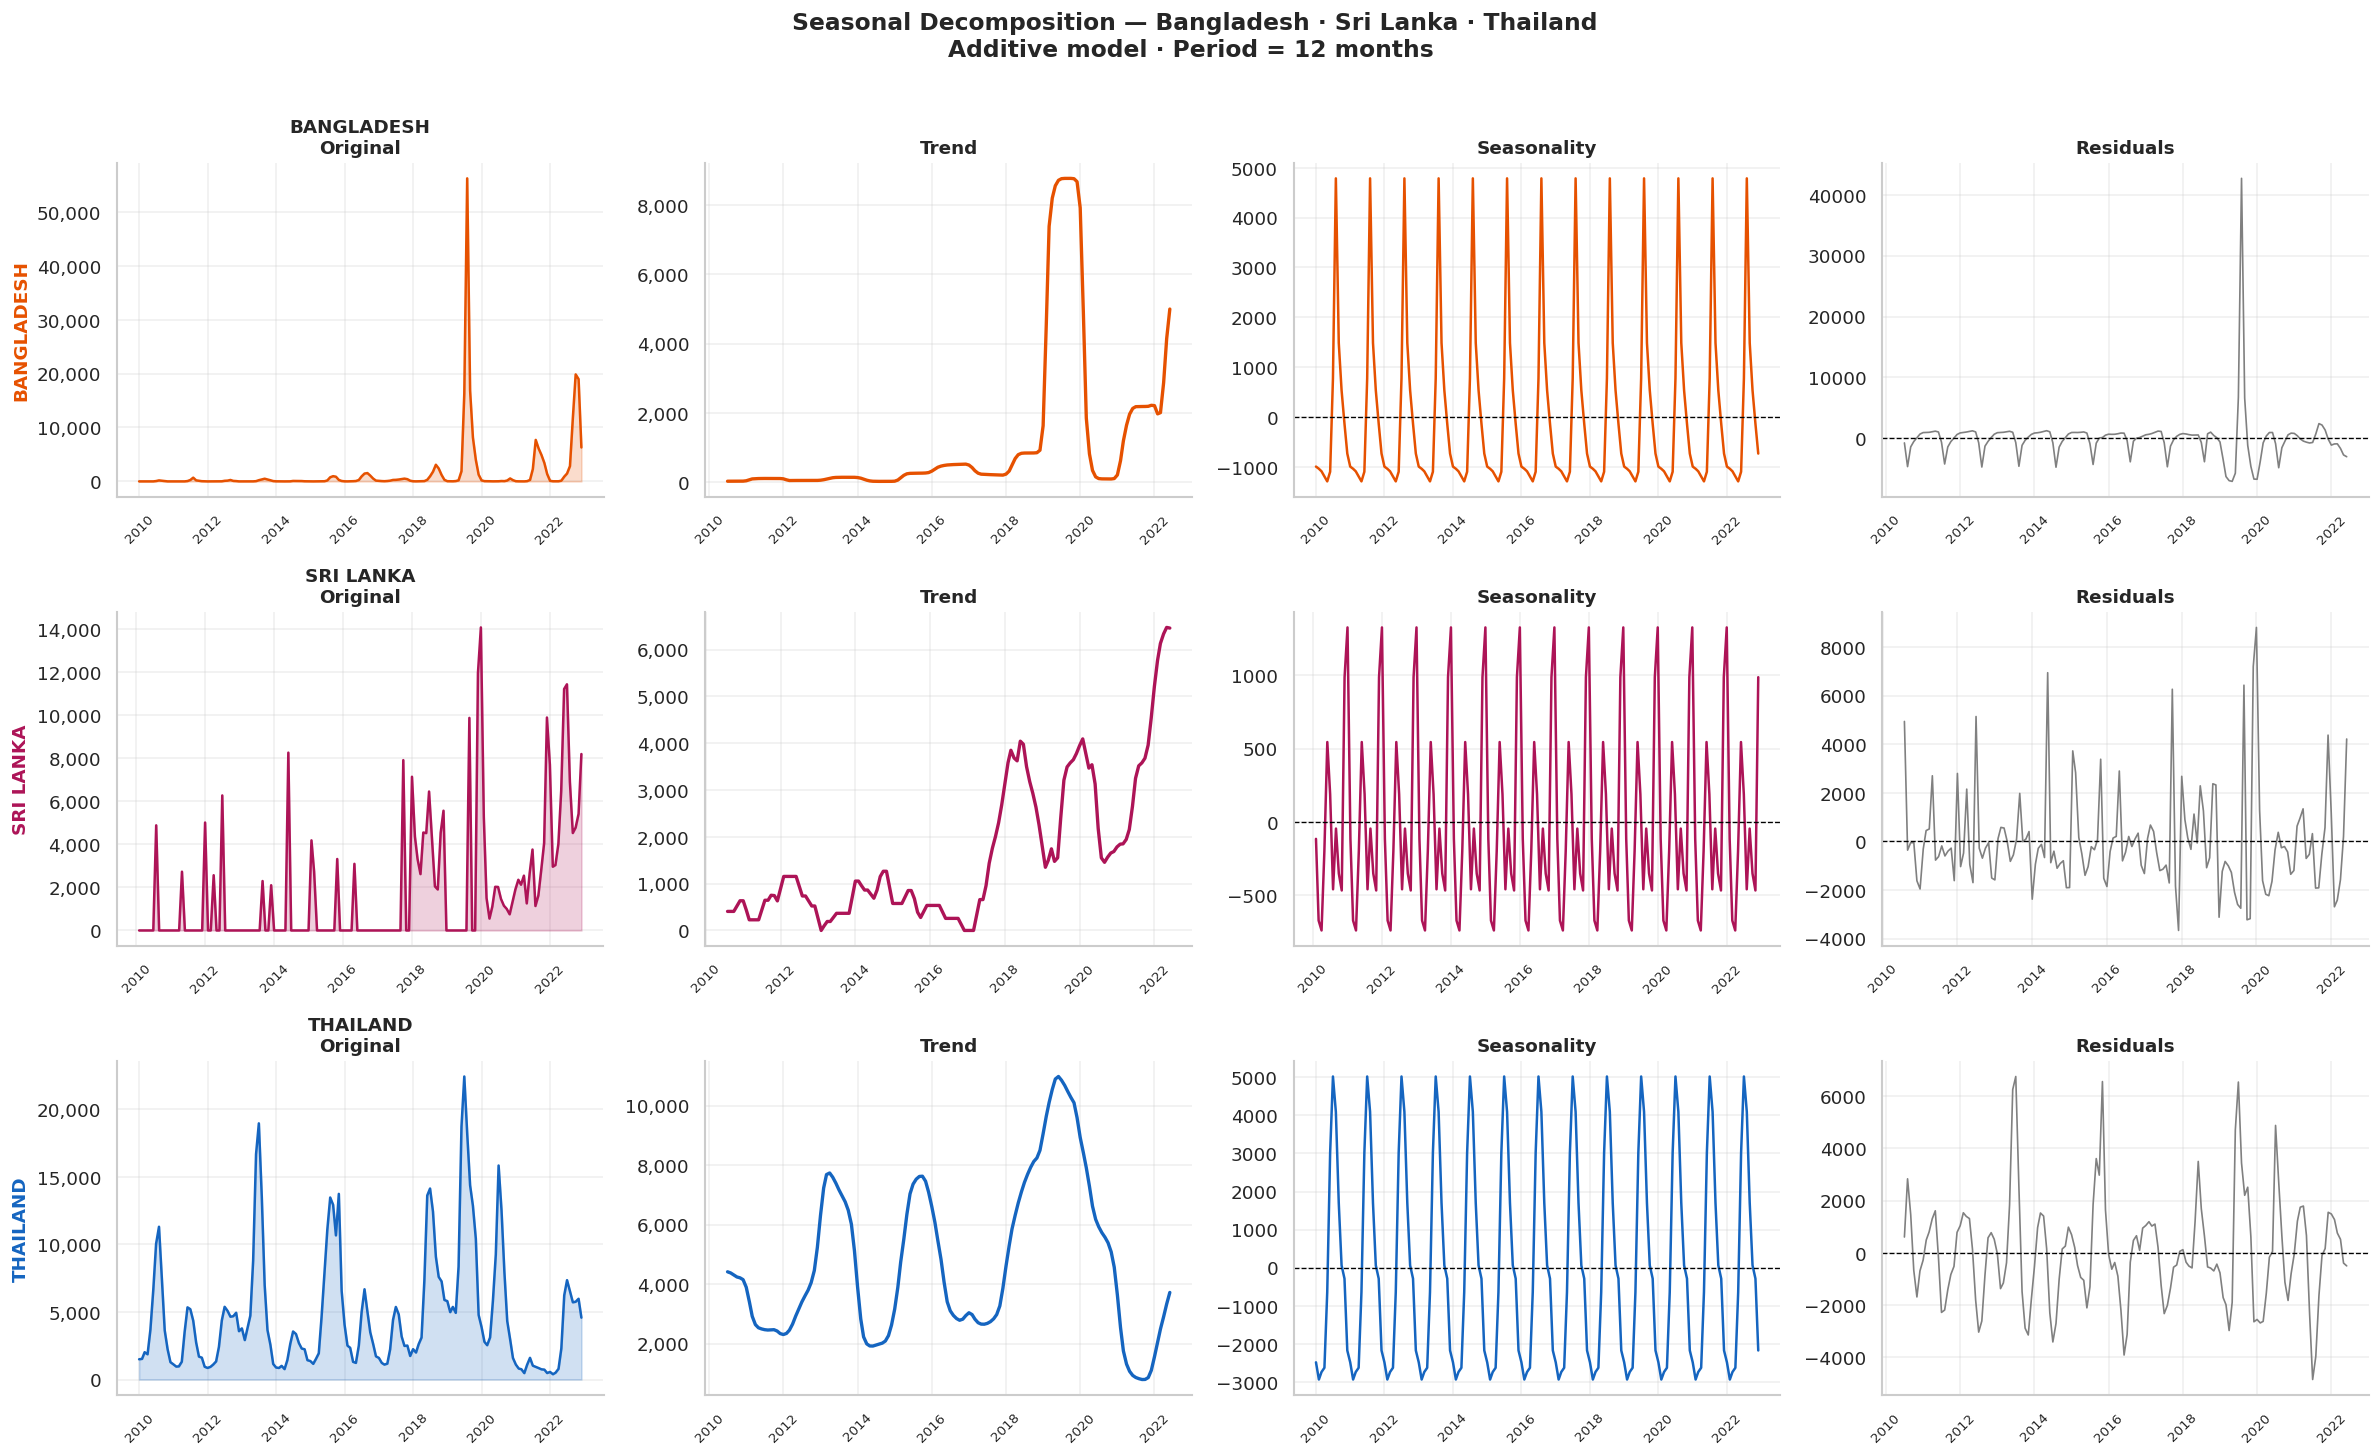


📌 Key findings:
  Bangladesh : Stationary — d=0, D=0
  Sri Lanka  : Non-stationary — d=1 needed before fitting
  Thailand   : Stationary — d=0, D=0


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

country_colors = {
    'BANGLADESH' : '#E65100',
    'SRI LANKA'  : '#AD1457',
    'THAILAND'   : '#1565C0',
}

for row_idx, (country, ts) in enumerate(ts_dict.items()):
    color = country_colors[country]

    # Decompose
    decomp = seasonal_decompose(ts, model='additive', period=12)

    # ── Original ──────────────────────────────────────────────────
    axes[row_idx, 0].plot(ts.index, ts.values, color=color, linewidth=1.5)
    axes[row_idx, 0].fill_between(ts.index, ts.values, alpha=0.2, color=color)
    axes[row_idx, 0].set_title(f'{country}\nOriginal', fontsize=11, fontweight='bold')
    axes[row_idx, 0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    # ── Trend ─────────────────────────────────────────────────────
    axes[row_idx, 1].plot(ts.index, decomp.trend, color=color, linewidth=2)
    axes[row_idx, 1].set_title('Trend', fontsize=11, fontweight='bold')
    axes[row_idx, 1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    # ── Seasonality ───────────────────────────────────────────────
    axes[row_idx, 2].plot(ts.index, decomp.seasonal, color=color, linewidth=1.5)
    axes[row_idx, 2].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    axes[row_idx, 2].set_title('Seasonality', fontsize=11, fontweight='bold')

    # ── Residuals ─────────────────────────────────────────────────
    axes[row_idx, 3].plot(ts.index, decomp.resid, color='grey', linewidth=1)
    axes[row_idx, 3].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    axes[row_idx, 3].set_title('Residuals', fontsize=11, fontweight='bold')

    # ── Row label ─────────────────────────────────────────────────
    axes[row_idx, 0].set_ylabel(country, fontsize=11, fontweight='bold', color=color)

    for ax in axes[row_idx]:
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle(
    ' Seasonal Decomposition — Bangladesh · Sri Lanka · Thailand\n'
    'Additive model · Period = 12 months',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── Stationarity note ─────────────────────────────────────────────
print("\n📌 Key findings:")
print("  Bangladesh : Stationary — d=0, D=0")
print("  Sri Lanka  : Non-stationary — d=1 needed before fitting")
print("  Thailand   : Stationary — d=0, D=0")

> 📌 **Observation — Seasonal Decomposition:**
>
> The decomposition reveals three distinct structural profiles:
>
> - 🇧🇩 **Bangladesh** — Trend shows near-zero activity until 2018 then explosive growth. Seasonality is extremely regular — sharp annual spikes of consistent shape. Residuals show one massive outlier around 2019 (the first major outbreak) — everything else is well-explained by trend + seasonality. **SARIMA should handle Bangladesh reasonably well in normal years but will completely miss the magnitude of first-time explosive outbreaks.**
>
> - 🇱🇰 **Sri Lanka** — Trend is irregular and non-monotonic — rises, falls, rises again. Seasonality exists but is inconsistent in magnitude across years. Residuals are large and noisy throughout — meaning a significant portion of Sri Lanka's dengue burden is unexplained by either trend or season. **This is the worst-case scenario for SARIMA — high residual variance means past patterns are a poor guide to the future.**
>
> - 🇹🇭 **Thailand** — Most textbook decomposition of the three. Trend shows clear multi-year epidemic cycles. Seasonality is strong, consistent, and regular — the same annual pattern repeating reliably every year. Residuals are relatively small. **This is exactly the kind of data SARIMA was designed for — Thailand is where we expect SARIMA to perform best.**
>
> **Key takeaway:** Decomposition alone already tells us SARIMA will perform differently across these three countries — well in Thailand, poorly in Sri Lanka, and unpredictably in Bangladesh. This spatial variation in SARIMA reliability is the foundation of our policy argument.

## 5.2 — ACF and PACF Analysis

Before fitting SARIMA we need to determine the model order — how many past values and past errors to include. We use two diagnostic plots:

**ACF (Autocorrelation Function)**
Shows how correlated the series is with its own past values at different lags. Significant spikes at seasonal lags (12, 24, 36) confirm seasonal patterns worth modelling.

**PACF (Partial Autocorrelation Function)**
Shows the direct correlation between the series and its lagged values, removing the effect of intermediate lags. Helps determine the AR order (p).

**What to look for:**
- Spikes at lag 12, 24 in ACF → strong seasonality → use seasonal component
- Sharp cutoff in PACF after lag p → use AR(p)
- Gradual decay in ACF → use MA terms

**Parameter selection guide:**
- p = last significant lag in PACF
- q = last significant lag in ACF
- d = 0 for Bangladesh/Thailand (already stationary), 1 for Sri Lanka
- P, D, Q = seasonal equivalents, D=1 for all (seasonal differencing)

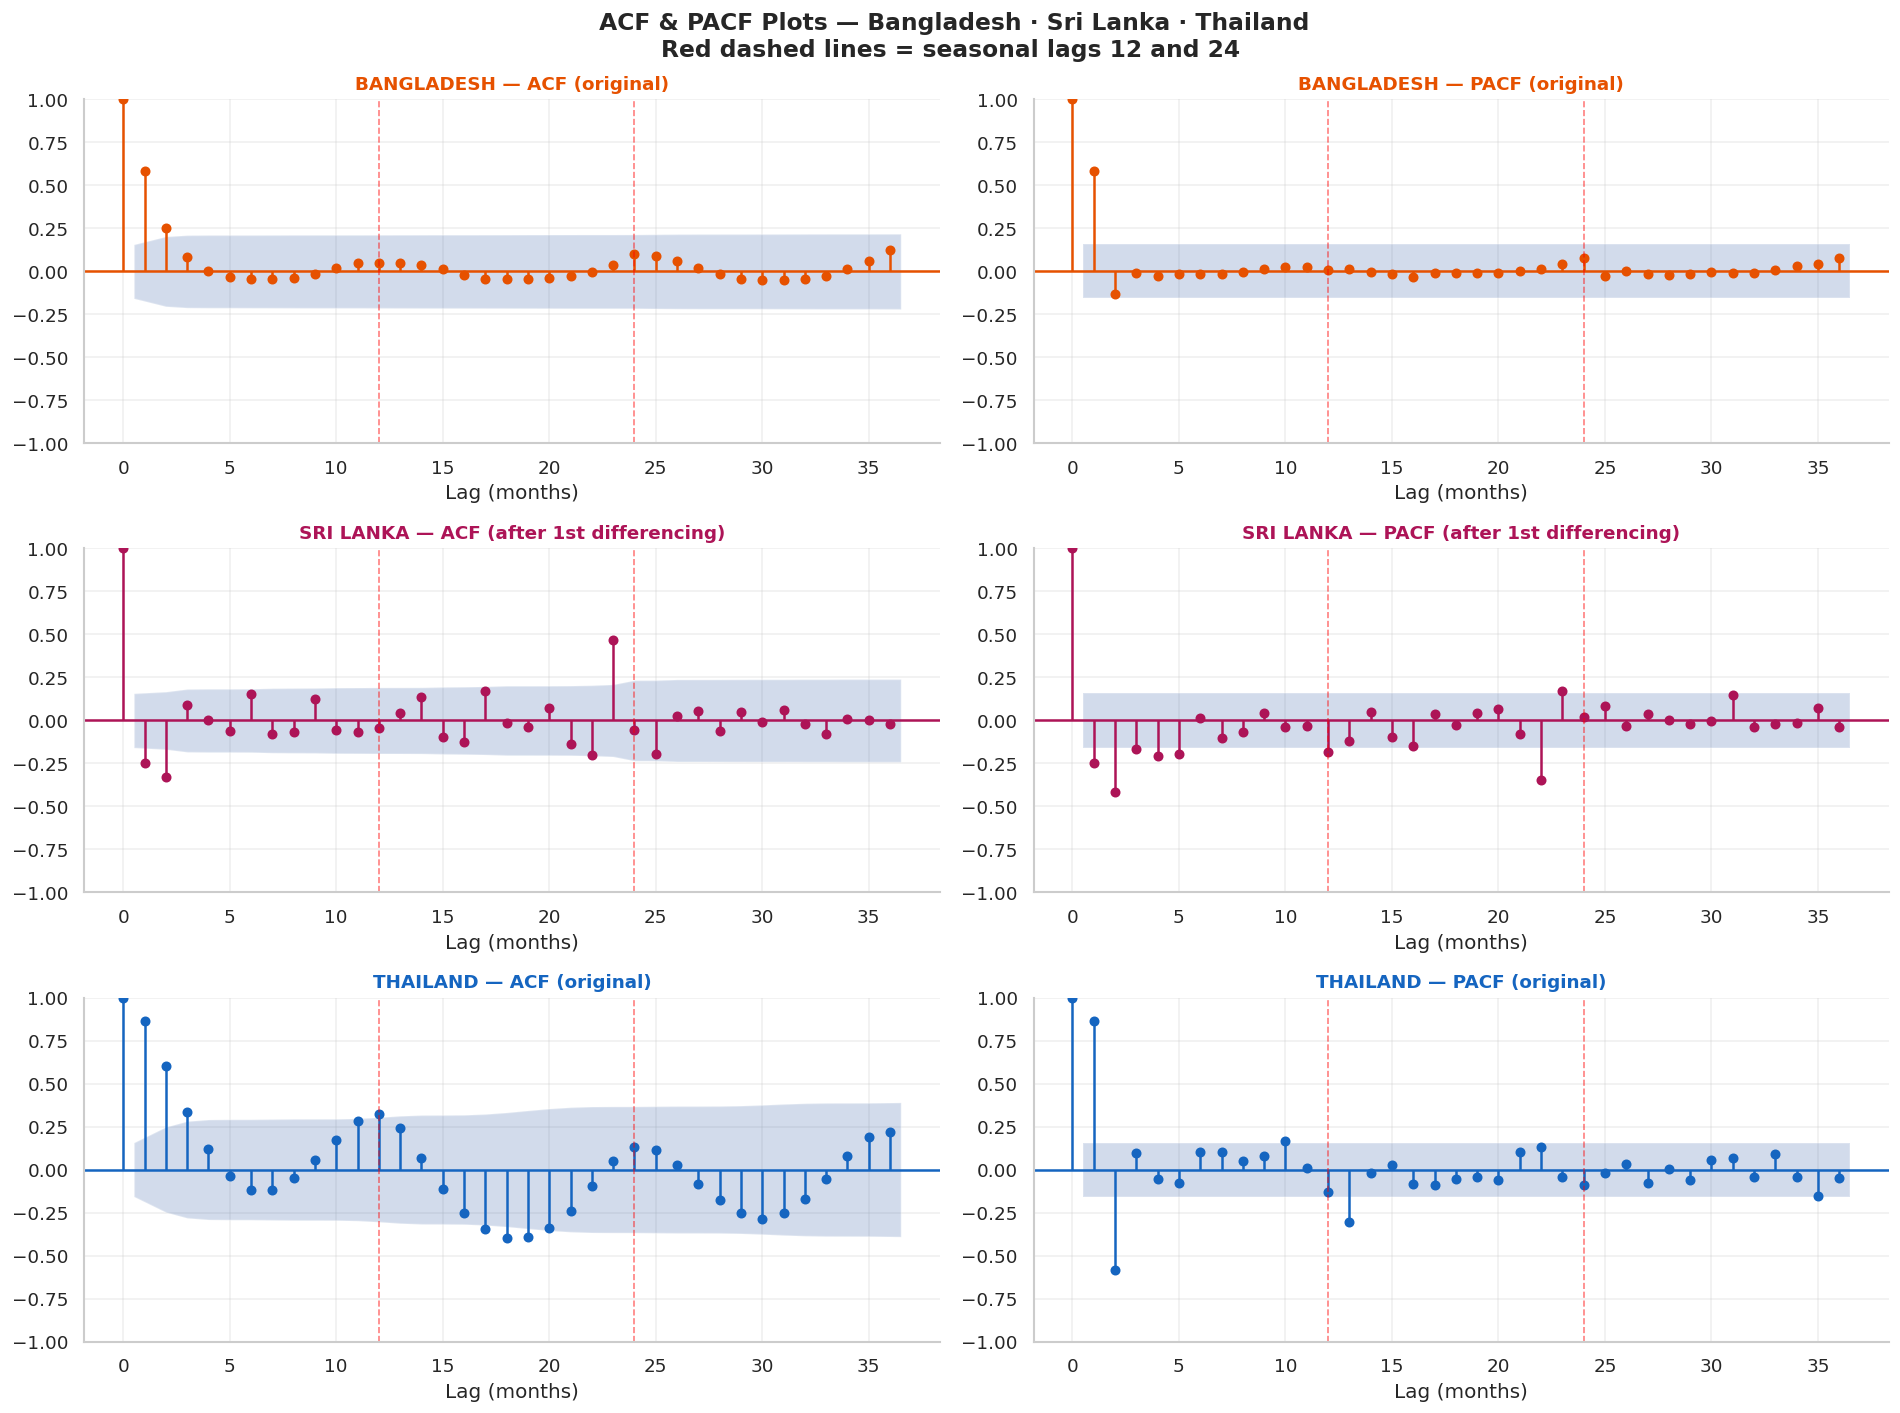


 Suggested SARIMA orders based on ACF/PACF:
──────────────────────────────────────────────────
  Bangladesh : SARIMA(1,0,1)(1,1,1)12
  Sri Lanka  : SARIMA(1,1,1)(1,1,1)12
  Thailand   : SARIMA(2,0,1)(1,1,1)12

  Note: Final orders confirmed by AIC in next cell


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

countries = ['BANGLADESH', 'SRI LANKA', 'THAILAND']
colors    = {
    'BANGLADESH' : '#E65100',
    'SRI LANKA'  : '#AD1457',
    'THAILAND'   : '#1565C0'
}

for row_idx, country in enumerate(countries):
    ts    = ts_dict[country]
    color = colors[country]

    # Apply differencing for Sri Lanka
    if country == 'SRI LANKA':
        ts_plot = ts.diff().dropna()
        title_suffix = '(after 1st differencing)'
    else:
        ts_plot = ts
        title_suffix = '(original)'

    # ── ACF ───────────────────────────────────────────────────────
    plot_acf(
        ts_plot,
        lags=36,
        ax=axes[row_idx, 0],
        color=color,
        vlines_kwargs={'colors': color}
    )
    axes[row_idx, 0].set_title(
        f'{country} — ACF {title_suffix}',
        fontsize=11, fontweight='bold', color=color
    )
    axes[row_idx, 0].set_xlabel('Lag (months)')
    axes[row_idx, 0].axvline(x=12, color='red', linestyle='--',
                              linewidth=1, alpha=0.5, label='Lag 12')
    axes[row_idx, 0].axvline(x=24, color='red', linestyle='--',
                              linewidth=1, alpha=0.5, label='Lag 24')
    axes[row_idx, 0].grid(True, alpha=0.3)

    # ── PACF ──────────────────────────────────────────────────────
    plot_pacf(
        ts_plot,
        lags=36,
        ax=axes[row_idx, 1],
        color=color,
        vlines_kwargs={'colors': color},
        method='ywm'
    )
    axes[row_idx, 1].set_title(
        f'{country} — PACF {title_suffix}',
        fontsize=11, fontweight='bold', color=color
    )
    axes[row_idx, 1].set_xlabel('Lag (months)')
    axes[row_idx, 1].axvline(x=12, color='red', linestyle='--',
                              linewidth=1, alpha=0.5, label='Lag 12')
    axes[row_idx, 1].axvline(x=24, color='red', linestyle='--',
                              linewidth=1, alpha=0.5, label='Lag 24')
    axes[row_idx, 1].grid(True, alpha=0.3)

    for ax in [axes[row_idx, 0], axes[row_idx, 1]]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle(
    ' ACF & PACF Plots — Bangladesh · Sri Lanka · Thailand\n'
    'Red dashed lines = seasonal lags 12 and 24',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n Suggested SARIMA orders based on ACF/PACF:")
print("─" * 50)
print("  Bangladesh : SARIMA(1,0,1)(1,1,1)12")
print("  Sri Lanka  : SARIMA(1,1,1)(1,1,1)12")
print("  Thailand   : SARIMA(2,0,1)(1,1,1)12")
print("\n  Note: Final orders confirmed by AIC in next cell")

> 📌 **Observation — ACF & PACF Analysis:**
>
> The plots confirm distinct autocorrelation structures across the three countries:
>
> - 🇧🇩 **Bangladesh** — ACF shows significant spike only at lag 1, dropping quickly into the confidence band. PACF cuts off sharply after lag 1. Very little seasonal signal at lags 12 and 24 — consistent with a recently emerging endemic where historical seasonal patterns are not yet well established. Suggested order: **SARIMA(1,0,1)(1,1,1)₁₂**
>
> - 🇱🇰 **Sri Lanka** — After first differencing, ACF shows a significant negative spike at lag 1 then a notable spike at lag 24. PACF shows spikes at lags 1, 2, and 12. The irregular pattern reflects Sri Lanka's noisy residuals seen in the decomposition — the series is hard to model cleanly. Suggested order: **SARIMA(1,1,1)(1,1,1)₁₂**
>
> - 🇹🇭 **Thailand** — Richest autocorrelation structure of the three. ACF shows significant spikes at lags 1, 2, 3 and clear seasonal spikes at lags 12 and 24 — confirming strong repeating annual cycles. PACF cuts off after lag 2. This is exactly the pattern SARIMA is built for. Suggested order: **SARIMA(2,0,1)(1,1,1)₁₂**
>
> **Key insight:** Thailand's ACF/PACF shows the cleanest seasonal signal — confirming it as the most SARIMA-friendly country. Bangladesh's weak autocorrelation structure is a warning sign that SARIMA may struggle to capture its explosive growth. Sri Lanka's irregular structure confirms our earlier finding that its dynamics are not well explained by historical patterns alone.